### Предсказательные модели: чем ИИ отличается от классической науки?
**Предсказательные модели.** Пусть мы хотим построить *предсказательную модель* $\mathbf y=f(\mathbf x)$, предсказывающую некоторую величину или характеристику $\mathbf y$, связанную с объектом $\mathbf x$. Объекты и характеристики могут быть самыми разными, но в компьютере они почти всегда описываются наборами чисел, поэтому мы будем считать, что $\mathbf x$ и $\mathbf y$ являются либо числами (*скалярами*), либо их упорядоченными наборами определенного размера (*векторами*). Векторы удобно обозначать жирным шрифтом, чтобы отделять их от скаляров.

**Обучение модели. Обучающие данные.** Формула $\mathbf y=f(\mathbf x)$ показывает, что математически $\mathbf y$ является *функцией* $\mathbf x$, то есть получается из $\mathbf x$ в результате некоторого вычисления. Ключевое отличие подхода ИИ от традиционных науки и технологий заключается в структуре рассматриваемых функций $f$ и способе их построения. А именно, традиционный подход предполагает, что функция $f$ описывается человеком некоторым явным способом (формулой, алгоритмом и т.п.) на основе научных или практических знаний. Подход же ИИ исходит из того, что функция $f$ слишком сложна для непосредственного явного описания. По этой причине человек задает не саму функцию $f$, а некоторую общую схему или класс функций, в рамках которого компьютер уже находит нужную функцию с помощью той или иной алгоритмической процедуры. Эта процедура называется *обучением модели* и, как правило, нуждается в *обучающих данных*.  

**Модели с простой теоретически мотивированной структурой.** Приведем следующий пример. Пусть мы кидаем вверх камень со скоростью $v_0$. Тогда, ввиду закона равноускоренного движения под действием силы тяжести, высота камня через время $t$ будет равна $h=h_0+v_0t-\frac{gt^2}{2},$ где $h_0$ - начальная высота, а $g$ - ускорение свободного падения. Мы можем рассматривать эту формулу как предсказательную модель $h=f(h_0, v_0, t)$, предсказывающую высоту камня как функцию начального положения, начальной скорости и момента времени. Предсказательная модель имеет простой математический вид благодаря явному знанию - закону равноускоренного движения Галилея. Этот закон был, разумеется, получен на основе опытных данных (экспериментов Галилея), и в этом смысле наша предсказательная модель основана на данных. Однако эта зависимость очень слабая - детали этих экспериментов не играют для нас сейчас, после установления закона, существенной роли; мы можем легко запрограммировать нашу предсказательную модель, используя лишь стандартные математические функции и не обращаясь ни к каким данным.

**Зависимости, не описываемые простыми функциями.** Рассмотрим теперь другой пример. Пусть мы хотим определить цифру по ее рукописному изображению. Ниже мы приводим примеры изображений из стандартного набора MNIST. Каждое изображение представляет собой массив размера $28\times 28$ из чисел в интервале $[0,1],$ отвечающих яркости соответствующих пикселей.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape of training array: (60000, 28, 28)


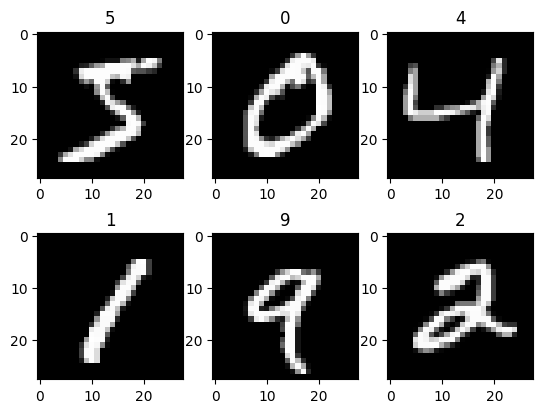

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

(Xtrain, Ytrain), (Xtest, Ytest) = mnist.load_data()

print ('Shape of training array:', Xtrain.shape)

for n in range(6):
    plt.subplot(2,3,n+1)
    plt.imshow(Xtrain[n], cmap='gray')
    plt.title(Ytrain[n])
plt.show()

Для человека определить цифру по ее изображению проще, чем предсказать высоту камня по начальной скорости и моменту времени. В этом смысле данная задача не сложнее предыдущей. Однако, в отличие от предыдущей, у нас нет никакой простой формулы, которая позволяла бы вычислить цифру как функцию яркости $28\times 28$ пикселей. Функциональная зависимость между цифрой и ее изображением, очевидно, существует, но не описывается никакими фундаментальными законами.

Как устроена эта зависимость? Мы можем привести здесь ряд соображений (далеко не исчерпывающий). Во-первых, у цифр есть типовые начертания, к которым близки различные варианты изображений. Во-вторых, у изображений цифр есть определенные *признаки*, которые помогают отличить одну цифру от другой, например острые углы в определенных местах или, наоборот, закругления. В-третьих, предсказательная модель должна быть устойчива по отношению к небольшим деформациям изображения, например сдвигам или поворотам. Эти и другие соображения можно использовать для построения и улучшения предсказательной модели, однако ни одно из них само по себе не дает четкого критерия классификации и не сводится к правилу, сопоставимому по простоте и универсальности с законом равноускоренного движения. Можно ожидать, что точная  предсказательная модель классификации цифр должна учитывать целый комплекс свойств изображений, и существенно зависеть от данных, т.е. имеющегося набора примеров (скажем, она будет совершенно неприменима к изображениям римских цифр).

> **Упражнение.** Попробуйте построить классификатор рукописных цифр, используя какое-то одно простое соображение. Например, используя данные MNIST, найдите усредненное изображение для каждой цифры (*барицентр класса*). Далее, определите некоторое расстояние между изображениями. Теперь для любого заданного изображения цифры мы можем сосчитать его расстояние до всех 10 усредненных изибражений, представляющих разные цифры, и взять в качестве прогноза цифру, отвечающему наименьшему расстоянию. Насколько точен такой классификатор? Проверьте визуально работу классификатора на нескольких десятках изображений - делает ли он ошибочные, с нашей точки зрения, предсказания? Почему это происходит, что не учитывает наша модель?

Train data shape: (60000, 28, 28)
Averaged digits:


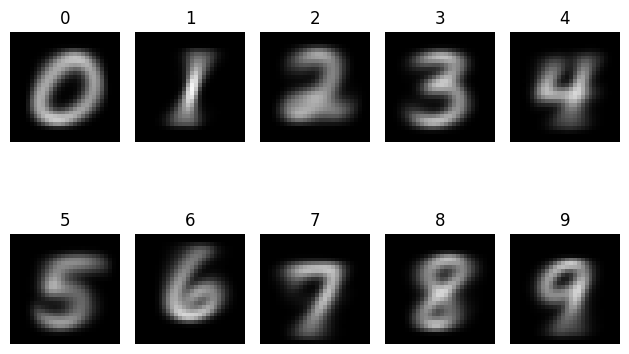

In [ ]:
print ('Train data shape:', Xtrain.shape)

Xmean = np.empty((10, 28, 28))
for n in range(10):
  Xmean[n] = np.mean(Xtrain[Ytrain == n,:,:], axis=0)

print ('Averaged digits:')

for n in range(10):
    plt.subplot(2,5,n+1)
    plt.imshow(Xmean[n], cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.title(n)
plt.tight_layout()
plt.show()

In [ ]:
def classifyByCenterDist(x):
    assert x.ndim == 3 and x.shape[1] == 28 and x.shape[2] == 28
    N = x.shape[0]
    distA = np.empty((N,10))
    for n in range(10):
        distA[:,n] = np.mean(np.abs(x-Xmean[n]), axis=(1,2))
    return np.argmin(distA, axis=1)

YtrainPred = classifyByCenterDist(Xtrain)
YtestPred = classifyByCenterDist(Xtest)

print ('Train accuracy:', np.mean(YtrainPred==Ytrain))
print ('Test accuracy:', np.mean(YtestPred==Ytest))
print ('Train error:', np.mean(YtrainPred!=Ytrain))
print ('Test error:', np.mean(YtestPred!=Ytest))

Train accuracy: 0.6513333333333333
Test accuracy: 0.6685
Train error: 0.3486666666666667
Test error: 0.3315


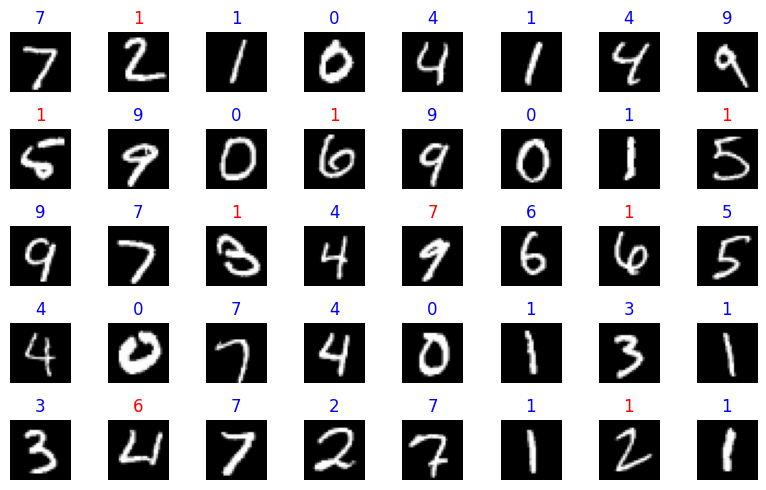

In [ ]:
plt.figure(figsize=(8,5))
for n in range(40):
    plt.subplot(5,8,n+1)
    plt.imshow(Xtest[n], cmap='gray')
    plt.title(YtestPred[n], color=['r','b'][int(YtestPred[n]==Ytest[n])])
    plt.axis('off')
plt.tight_layout()
plt.show()

**Машинное обучение.** Таким образом, задача распознавания рукописных цифр требует совершенно иного подхода, нежели задача прогнозирования высоты летящего камня, - а именно подхода на основе *машинного обучения*. Вместо того, чтобы пытаться сходу описать интересующую нас зависимость простой, явной и наглядно интерпретируемой функцией (что невозможно или дает слишком низкую точность), мы задаем некоторый широкий класс функций, и дальше пытаемся уточнить функцию внутри этого класса с помощью имеющихся данных, т.е. собственно *обучить модель*.

**Обучение с учителем и другие типы обучения.** Приведенный пример задачи классификации рукописных цифр относится к типу задач *обучения с учителем* (*supervised learning*). Это означает, что мы хотим построить предсказательную модель $\mathbf y=f(\mathbf x)$ исходя из имеющихся у нас примеров $(\mathbf x_n, \mathbf y_n)$, содержащих как входные объекты $\mathbf x_n$, так и соответствующие отклики (метки) $\mathbf y_n$. Такие обучающие данные называют *размеченными*. Оценка модели обычно состоит просто в применении ее к новым объектам $\mathbf x$ и сравнении результатов $f(\mathbf x)$ с истинными откликами $\mathbf y$. В машинном обучении существуют и другие типы задач. Под *обучением без учителя* обычно понимают задачи, в которых в данных нет примеров откликов $\mathbf y$. Характерным примером является *кластеризация*: нам дается набор объектов $\mathbf x_n,$ который мы должны разбить на несколько кластеров (т.е., групп в том или ином смысле близких объектов). Например, векторы $\mathbf x_n$ могут представлять генотипы живых существ, которые мы хотим разбить на по возможности естественные биологические группы. В отличие от обучения с учителем, в задачах без учителя нет одного естественного способа оценки модели, и задача может иметь разные решения. Существуют задачи, промежуточные между указанными двумя типами или со специфической структурой данных. Например, в задаче генерации текстов в качестве обучающих данных обычно используются тексты, разметка которых порождается автоматически: текущий символ или слово считается откликом предыдущего участка текста (*самообучение, self-supervised learning*).  В данной главе мы будем рассматривать только задачи обучения с учителем в обычном общем формате, предполагающем наличие выборки примеров $(\mathbf x_n, \mathbf y_n)$.

   


### Параметрические модели, классификация и регрессия, функция потерь, бинарное кодирование, обобщающая способность

**Параметрические модели, оптимизация, функции потерь.** Как правило, класс функций задается с помощью *параметрических моделей*. Это означает, что мы ищем нашу зависимость в виде $\mathbf y=f(\mathbf x,\mathbf w)$, где $\mathbf w$ - вектор *параметров* (в контексте линейных моделей и нейронных сетей называемых также *весами*). Например, упомянутая выше модель классификации цифр с помощью расстояний до центров кластеров имеет параметрический вид

$$f(\mathbf x)=\operatorname{arg min}_{k=0,\ldots,9}\operatorname{dist}(\mathbf x, \mathbf w_k),$$

где $\operatorname{dist}$ - некоторая функция расстояния между векторами, а $\mathbf w_k$ - центры кластеров, отвечающих изображениям цифр от 0 до 9. Полный вектор весов получается перечислением всех центров, $\mathbf w=(\mathbf w_0,\ldots,\mathbf w_k)$. В этом примере векторы параметров $\mathbf w_k$ находятся простым усреднением соответствующих изображений. Однако в общем случае, для более сложных моделей, у нас не будет простого способа сразу же указать веса. Вместо этого обычно используется *итеративная оптимизация*. Мы начинаем с того, что определяем *функцию потерь* $L(\mathbf w)$, показывающую насколько хорош данный набор весов (чем меньше $L(\mathbf w)$, тем лучше). После этого мы применяем некоторый *оптимизационный алгоритм*, который пытается подобрать наилучший набор весов.

**Задачи классификации и регрессии.** Приведем примеры стандартных функций потерь, но сначала обратим внимание на разные типы предсказательных моделей с точки зрения типа отклика $\mathbf y$. В нашем первом примере (высота брошенного камня) предсказанием может быть любое число, в то время как во втором (цифра) предсказание дискретно и заключается в выборе одного из 10 возможных вариантов. Задачи первого типа обычно называют *задачами регрессии*, а второго - *задачами классификации*; соответствующие варианты называют *классами*. Для задач регрессии и классификации обычно используют разные функции потерь.

**Среднеквадратичное отклонение.** Ситуация с регрессией более простая - здесь стандартной функцией потерь является *среднеквадратичное отклонение (СКО)*. Пусть $(\mathbf x_n, y_n)_{n=1}^N$ - имеющийся набор данных из $N$ элементов; $y_n$ - истинный признак объекта $\mathbf x_n$, который мы хотим воспроизвести нашей моделью $f$. Тогда СКО определяется как

$$L_2(\mathbf w)=\frac{1}{N}\sum_{n=1}^N(f(\mathbf x_n,\mathbf w)-y_n)^2.$$

Если функция $f$ идеально воспроизводит значения $y_n$ на всех точках $\mathbf x_n$, то $L_2(\mathbf w)=0$; в противном случае $L_2(\mathbf w)>0$.

**Среднее и максимальное отклонения.** Иногда удобно рассматривать другие характеристики точности регрессии, например *среднее отклонение*

$$L_1(\mathbf w)=\frac{1}{N}\sum_{n=1}^N|f(\mathbf x_n,\mathbf w)-y_n|$$

или *максимальное отклонение*

$$L_\infty(\mathbf w)=\max_{n=1,\ldots,N}|f(\mathbf x_n,\mathbf w)-y_n|.$$

> **Упражнение.** Покажите, что $(L_1(\mathbf w))^2\le L_2(\mathbf w)\le (L_\infty(\mathbf w))^2$.

**Усреднения точечных функций потерь.** Отметим, что функции потерь $L_1$ и $L_2$ имеют общий структурный вид усреднения значений некоторой *точечной* функции потерь $\ell(\mathbf x, \mathbf w)$ по всем точкам обучающих данных:

$$L(\mathbf w)=\frac{1}{N}\sum_{n=1}^N \ell(\mathbf x_n, \mathbf y_n, \mathbf w).$$

Это типичный общий вид функции потерь. Он показывает, что для минимизации полной функции потерь $L$ нужно по возможности уменьшить значения $\ell(\mathbf x_n, \mathbf y_n, \mathbf w)$ в имеющихся точках $\mathbf x_n$. В общем случае невозможно выбрать $\mathbf w$ так, чтобы одновременно минимизировать $\ell(\mathbf x_n, \mathbf y_n, \mathbf w)$ во всех точках $\mathbf x_n$;  в этом смысле функция $L$ определяет некоторый компромисс.

СКО особенно удобно с точки зрения рассматриваемой далее градиентной оптимизации.

> **Упражнение.** Пусть функция $f$ непрерывно дифференцируемая. Проверьте, что $L_2(\mathbf w)$ также непрерывно дифференцируема, а $L_1(\mathbf w)$ и $L_\infty(\mathbf w)$ - вообще говоря, нет.

> **Общее понятие усреднения.** Выше мы написали среднее значение функции $f$, заданной в $N$ точках $\mathbf x_1,\ldots,\mathbf x_N$, как $\tfrac{1}{N}\sum_{n=1}^N f(\mathbf x_n)$. Это подразумевает, что мы берем каждую из точек $\mathbf x_n$ с вероятностью $\tfrac{1}{N}$. Существует более общее понятие *среднего значения* (или *математического ожидания*) функции, связанное с любой *вероятностной мерой* $\rho$ на множестве точек $\mathbf x$. Такое среднее обычно записывается $\mathbb E_{\mathbf x\sim \rho}[f(\mathbf x)]$ и в общем случае дается интегралом $\int f(\mathbf x)\rho(d\mathbf x)$. Если мера $\rho$ дискретная, так что существует последовательность точек $\mathbf x_n$ и соответствующих вероятностей $p_n=\rho(\mathbf x_n)$, в сумме дающих 1, то среднее принимает вид $\sum_n p_n f(\mathbf x_n)$. Другой специальный случай - если $\mathbf x$ это числа или векторы и мера $\rho$ имеет плотность $p(\mathbf x)$ по отношению к стандартной мере Лебега (задающей обычную длину, площадь, объем и т.д.). Например, если $\rho$ - равномерное распределение на отрезке $[a,b]$, то $\mathbb E_{\mathbf x\sim \rho}[f(\mathbf x)]=\tfrac{1}{b-a}\int_{a}^{b}f(x)dx$. В теоретическом машинном обучении вероятностные меры $\rho$ обычно отвечают распределениям данных.   

**Функции потерь для классификации. Точность.** В случае задач классификации ситуация более интересная.  Простейшей и наиболее естественной для общей оценки модели функцией потерь является *точность* (accuracy) модели, определяемая просто как доля верно предсказанных классов:

$$L_{\mathrm{acc}}(\mathbf w)=\frac{1}{N}\sum_{n=1}^N \mathbf 1(f(\mathbf x_n,\mathbf w)=y(\mathbf x_n)),$$

где $\mathbf 1$ - индикаторная функция, равная 0 или 1 в зависимости от выполнения условия в аргументе.

Однако, с этой функцией связаны две (родственные) проблемы. Во-первых, функция $L_{\mathrm{acc}}$ кусочно постоянна (так как каждое из слагаемых $\mathbf 1(f(\mathbf x_n,\mathbf w)=y(\mathbf x_n))$ кусочно постоянно как функция от $\mathbf w$). Это не позволяет применять для оптимизации градиентные алгоритмы, поскольку градиент $L(\mathbf w)$ в любой точке $\mathbf w$ либо равен 0, либо вообще не существует. Во-вторых, функция $L_{\mathrm{acc}}$ отвечает *жесткой классификации*.  

**Жесткая классификация.** Функция $L_{\mathrm{acc}}$ предполагает, что мы имеем дело с *четкой* (*жесткой*) *классификацией*, в том смысле, что для любого объекта $\mathbf x_n$ мы даем вполне определенное предсказание одного из классов. Однако на практике модель практически никогда не бывает на 100% уверена в своих предсказаниях. Например, в приведенном примере классификации на основе расстояний до центров классов найдется много изображений, расстояния от которых до нескольких центров примерно одинаковы, так что выбор одного из соответствующих классов приблизительно случаен. Даже если нам нужна четкая классификация, информация о сравнительной уверенности модели в своих предсказаниях является довольно ценной для ее обучения: мы можем отслеживать прогресс обучения по тому, насколько растет уверенность модели в предсказании истинных классов.

**Мягкая классификация.** По этой причине в ходе обучения обычно удобнее рассматривать *мягкую* классификацию, предполагая, что для каждого объекта $\mathbf x$ и для каждого класса $c$ модель выдает величину $у_c(\mathbf x),$ выражающую степень  уверенности модели в этом классе объекта. Без ограничения общности можно считать значения $у_c(\mathbf x)$ неотрицательными и в сумме дающими 1 для каждого $\mathbf x$; тогда их можно интерпретировать как *вероятности классов*.

**Бинарное кодирование.** В соответствии с этим в случае классификации с $C$ классами удобно считать, что выходом $\mathbf y$ модели является $C$-мерный вектор с компонентами, отвечающими отдельным классам. (В некотором смысле можно сказать, что полная векторнозначная модель состоит из $C$ скалярных моделей, отвечающих разным классам.) В случае жесткой классификации модель возвращает один из координатных векторов $\mathbf y=(0,\ldots,0,1,0,\ldots,0)$.

> **Пример.** В задаче MNIST 10 классов, отвечающих цифрам 0-9; поэтому классификаторы обычно возвращают 10-мерный вектор. Отметим, что в данной задаче классы имеют естественную числовую интерпретацию, поэтому жесткий классификатор может быть и скалярным. Однако для мягких классификаторов один скалярный выход не обеспечивает достаточных выразительных возможностей. Например, если модель решает, что изображение с равной вероятностью отвечает цифрам 2 или 8, то было бы нелепо выдавать "усредненный результат" $(2+8)/2=5,$ так как арифметическое усреднение меток классов никак не связано с усреднением числовых массивов, описывающих изображения. Гораздо логичнее выдавать вектор вероятностей $(0,0,\tfrac{1}{2},0,0,0,0,0,\tfrac{1}{2},0)$.


**Софтмакс.** Если мы хотим, чтобы выходы $y_c(\mathbf x)$ классификационной модели с бинарным кодированием классов имели вероятностную интерпретацию, то нам нужно обеспечить условия $y_c(\mathbf x)\ge 0$ и $\sum_{c=1}^C y_c(\mathbf x)=1$ для любых входных данных $\mathbf x$. Обычно это делается с помощью операции *софтмакс*. Пусть $\mathbf z$ - любой $C$-мерный вектор. Определим $\mathbf y=\operatorname{softmax}(\mathbf z)$ как новый $C$-мерный вектор с компонентами

$$y_c=\frac{e^{z_c}}{\sum_{c'=1}^C e^{z_{c'}}}.$$

Легко проверить (**упражнение**), что для этого вектора выполняются условия $y_c\ge 0$ и $\sum_{c=1}^C y_c=1$. Таким образом, если у нас есть модель, выдающая для заданного входа какой-то $C$-мерный вектор $\mathbf z$ (вообще говоря, с неположительными и не дающими в сумме 1 компонентами), то мы всегда можем перейти к модели с вероятностно-интерпретируемыми выходами просто применяя к $\mathbf z$ софтмакс. Софтмакс монотонен в том смысле, что для любых классов  $c,c'$ неравенство $z_c<z_{c'}$ выполнено тогда и только тогда, когда $y_c<y_{c'}$. Поэтому величины $(z_c)_{c=1}^C$ находятся на числовой оси в том же порядке, что и величины $(y_c)_{c=1}^C$; в частности, наиболее вероятный класс отвечает максимальному $z_c$.  

> **Практическое вычисление softmax.** Заметим, что вычисление softmax непосредственно по приведенной формуле с быстрорастущей функцией $e^z$ на реальном компьютере не всегда возможно ввиду ограниченных возможностей представления чисел. Например, в стандарте представления чисел с одинарной точностью (single precision float) максимально возможное число примерно равно $10^{38}$. Уже при $z=100$ мы получаем $e^z\approx 10^{43}>10^{38},$ так что попытка напрямую применить формулу приводит к неопределенности $\tfrac{\infty}{\infty}$. Мы, можем, однако, использовать эквивалентную, но более широко применимую форму softmax. А именно, заметим, что результат softmax не изменится, если из каждого $z_c$ вычесть одну и ту же константу. В частности, вы можем вычесть константу, равную $\max_c z_c$. Новые значения $z'_c=z_c-\max_{c'} z_{c'}$ будут неположительными, и как минимум одно из них (на котором достигается максимум) будет равно нулю. Как следствие, знаменатель формулы softmax для нового набора $z'_c$ лежит в интервале $[1,C]$ и отделен как от нуля, так и от бесконечности. Числители же $e^{z'_c}$ лежат в интервале $[0,1],$ причем по меньшей мере один из них равен 1. В этой ситуации деление уже не вызывает трудностей; в случае большого по модулю отрицательного $z'_c$ экспонента $e^{z'_c}$ будет округлена до нуля и соответствующая компонента softmax также будет вычислена как 0.    

Если модель такова, что ее компоненты выхода $z_c$ уже неотрицательны, но в сумме не дают 1, то вместо софтмакса для перехода к вероятностям можно просто поделить компоненты на их сумму:

$$y_c=\frac{{z_c}}{\sum_{c'=1}^C z_{c'}}.$$

TODO: консистентные обозначения для точечных функций потерь

**Кросс-энтропийная функция потерь.** Мы готовы теперь обсудить функции потерь для классификации. Пусть модель использует бинарное кодирование и для каждого входа $\mathbf x$ выдает $C$-мерный вектор $\mathbf p(\mathbf x,\mathbf w)$ вероятностей классов. Пусть $\mathbf q_n=(q_{n,1},\ldots,q_{n,C})$ - $C$-мерный вектор, представляющий с помощью бинарного кодирования соответствующий истинный класс в точке данных $\mathbf x_n$. Стандартной для классификации является *кросс-энтропийная функция потерь*

$$L_{\mathrm{CE}}(\mathbf w)=\frac{1}{N}\sum_{n=1}^N \ell(\mathbf x_n,\mathbf w),\quad \ell(\mathbf x,\mathbf w)=-\sum_{c=1}^Cq_c(\mathbf x)\ln p_c(\mathbf x,\mathbf w).$$

Если обозначить через $c(\mathbf y)$ истинный класс объекта $\mathbf x$, то точечную функцию потерь $\ell(\mathbf x,\mathbf w)$ можно также записать в более простом виде

$$\ell(\mathbf x,\mathbf w)=-\ln p_{c(\mathbf x)}(\mathbf x,\mathbf w).$$

Так как функция $-\ln(x)$ на интервале $[0,1]$ монотонно убывает от $+\infty$ до 0, мы видим, что минимизация функции потерь эквивалентна максимизации вероятности предсказания истинного класса.

Оговоримся, что для классификации можно использовать и другие функции потерь, например среднеквадратичную ошибку:

$$L(\mathbf w)=\frac{1}{N}\sum_{n=1}^N \ell(\mathbf x_n,\mathbf w),\quad \ell(\mathbf x,\mathbf w)=\frac{1}{C}\sum_{c=1}^C(q_c(\mathbf x)- p_c(\mathbf x,\mathbf w))^2.$$

Минимизация такой функции потерь также заставляет модель увеличивать вероятность истинного класса и уменьшать вероятность остальных классов в своих предсказаниях.


> **Упражнение.** Реализуйте построенный ранее классификатор рукописных цифр как мягкий классификатор. Реализуйте для него стандартные функции потерь: среднеквадратичную, кросс-энтропийную и точность.

**Градиентный спуск.** Существуют разные алгоритмы минимизации функции потерь $L(\mathbf w)$. Простейший алгоритм заключается в простом переборе различных (например, случайных) значений $\mathbf w$. Разумеется, этот алгоритм крайне неэффективнен. Простой, но эффективный алгоритм *градиентный спуск* имеет итеративный вид

$$\mathbf w_{n+1}=\mathbf w_n-\alpha\nabla L(\mathbf w_n),$$

где $\alpha>0$ - положительный *параметр шага* (learning rate), а $\nabla L(\mathbf w_n)$ - градиент функции потерь. Очевидными достоинствами этого алгоритма являются его простота и универсальность. Его эффективность для обучения нейронных сетей и других моделей машинного обучения связана с двумя обстоятельствами:

1. Функции потерь больших нейронных сетей обычно имеют не слишком сложный рельеф в том смысле, что оптимизация градиентным спуском достаточно надежно сходится к хорошим минимумам. Интересно, что надежность оптимизации может улучшаться при увеличении размера сети, в связи с тем, что благодяря дополнительным степеням свободы как бы появляется больше возможностей оптимизации.
2. Оказывается, что если функция $L(\mathbf w)$ задана некоторым пусть сложным, но явным аналитическим выражением, то вычисление $\nabla L(\mathbf w_n)$ требует числа элементарных операций, сопоставимого с требуемым для вычисления самого значения $L(\mathbf w)$. Этот удивительный и важный математический факт позволяет вычислять $\nabla L(\mathbf w_n)$ для моделей с миллионами и миллиардами весов.

Быстрое вычисление градиента трубует использования специальных библиотек автоматического дифференцирования, таких как pytorch.

**Стохастический градиентный спуск.** Используемые на практике алгоритмы обучения нейронных сетей имеют в качестве основы градиентный спуск, но также включают ряд дополнительных модификаций. Наиболее важная из них называется *стохастическим градиентным спуском* (Stochastic Gradient Descent, SGD) и заключается в следующем. Как уже указывалось, минимизируемая функция потерь $L$ как правило имеет вид усредненной поточечной функции потерь, вычисляемой по всей обучающей выборке: $L(\mathbf w)=\frac{1}{N}\sum_{n=1}^N \ell(\mathbf x_n,\mathbf w)$. Градиент $\nabla L$ также является усреднением соответствующих градиентов: $\nabla L(\mathbf w)=\frac{1}{N}\sum_{n=1}^N \nabla_{\mathbf w} \ell(\mathbf x_n,\mathbf w)$. Таким образом, на каждом шаге градиентного спуска для вычисления $\nabla L$ нам требуется сосчитать и затем усреднить $N$ градиентов $\nabla_{\mathbf w}\ell(\mathbf x_n,\mathbf w)$. Общее число элементарных операций, необходимых для выполнения всего оптимизационного алгоритма, получается как произведение числа шагов градиентного спуска, размера выборки и числа элементарных операций для вычисления одного градиента $\nabla_{\mathbf w} \ell(\mathbf x_n,\mathbf w)$. В больших реальных задачах машинного обучения все эти множители являются большими числами. Даже с учетом упомянутой возможности быстрого вычисления градиента, общий объем требуемых вычислений оказывается нереалистично большим. Заметим, однако, что вместо вычисления и усреднения градиента на всей обучающей выборке мы можем оценить его по подвыборке $B$ небольшого размера $b$:

$$\nabla L_{B}(\mathbf w)=\frac{1}{b}\sum_{\mathbf x_n\in B} \nabla_{\mathbf w} \ell(\mathbf x_n,\mathbf w)$$

Естественно выбирать разные подвыборки на разных шагах градиентного спуска.
На практике полная обучающая выборка обычно просто предварительно разбивается на последовательные кусочки (*батчи*) $B_1, B_2,\ldots$ размера $b$, и градиентный спуск последовательно и циклически обходит эти кусочки. Одной *эпохой* обучения называют однократный проход по всем батчам. Размер батча $b$ обычно выбирается исходя из вычислительных возможностей компьютера, прежде всего размера памяти.

Очевидно, что стохастический градиентный спуск ускоряет каждый шаг алгоритма в $N/b$ раз, но ценой некоторого искажения (зашумления) истинного градиента $\nabla L(\mathbf w)$ - именно с этим связано слово "стохастический" в названии. Оказывается, что такое зашумление может быть даже полезным - оно придает дополнительные поисковые возможности алгоритму.


**Обобщающая способность.** В машинном обучении имеется важное разделение между *обучающими* и *тестовыми* выборками данных:

- *Обучающая* выборка служит для построения предсказательной модели;
- *Тестовая* выборка служит для проверки *предсказательной способности* обученной модели.

Обучающая и тестовая выборки не должны пересекаться (иначе проверка будет некорректной).

Отметим, что в классической науке предсказательная способность любой теории или модели также является ключевым фактором успешности этой теории или модели. Например, приведенный в начале пример зависимости $h=h_0+v_0t-\frac{gt^2}{2}$ высоты объекта от времени и начальных данных также, разумеется, обладает надежно и многократно проверенной предсказательной способностью. Однако, в отличие от классической науки, в машинном обучении оценка предсказательной способности во мноих случаях является практически *единственным* фактором успешности. Зависимость $h=h_0+vt-\frac{gt^2}{2}$ обладает, помимо предсказательной способности, другими важными достоинствами, например структурной простотой и согласованностью с законом сохранения энергии $\frac{m \dot v^2}{2}+mgh=const$. В случае же машинного обучения структурные свойства не играют такой важной роли: мы в принципе готовы рассматривать модели любой структуры и пользоваться ими как "черными ящиками".          

Как правило, функция потерь и доля ошибочных предсказаний на тестовой выборке превосходят соответствующие значения на обучающей выборке. Если эта разница  велика, то говорят, что модель *переобучена*. Переобучение является типичным явлением в моделях с большим числом параметров и неудачной внутренней структурой.

**Зависимость обобщающей способности от сложности модели.** Зависимость точности модели от сложности часто иллюстрируют следующим условным графиком:

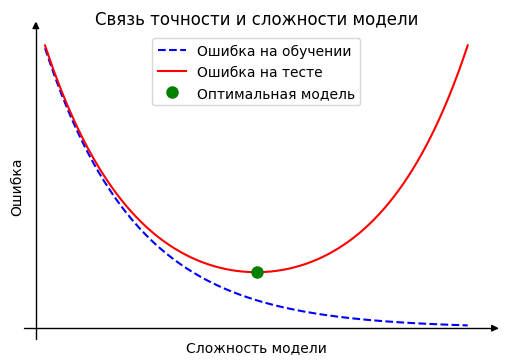

In [ ]:
from mpl_toolkits.axisartist.axislines import SubplotZero
import matplotlib.pyplot as plt
import numpy as np


fig = plt.figure(figsize=(6,4))
ax = SubplotZero(fig, 111)
fig.add_subplot(ax)

for direction in ["xzero", "yzero"]:
    # adds arrows at the ends of each axis
    ax.axis[direction].set_axisline_style("-|>")

    # adds X and Y-axis from the origin
    ax.axis[direction].set_visible(True)

for direction in ["left", "right", "bottom", "top"]:
    # hides borders
    ax.axis[direction].set_visible(False)

comp_min = 0.1
complexity = np.linspace(comp_min, 10, 1000)


train_error = 1/complexity
test_error = 1/complexity+complexity

plt.plot(0.1+np.log(complexity/comp_min), train_error, '--', label='Ошибка на обучении',  color='blue')
plt.plot(0.1+np.log(complexity/comp_min), test_error, label='Ошибка на тесте', color='red')

optimal_complexity_idx = np.argmin(test_error)
optimal_complexity = complexity[optimal_complexity_idx]
optimal_test_error = test_error[optimal_complexity_idx]
plt.plot(0.1+np.log(optimal_complexity/comp_min), optimal_test_error, 'go',
         markersize=8, label='Оптимальная модель')

ax.set_xticks([])
ax.set_yticks([])

plt.title('Связь точности и сложности модели')
plt.xlabel('Сложность модели')
plt.ylabel('Ошибка')
plt.legend()

plt.show()

Рисунок показывает, что при увеличении сложности модели ее точность на обучающей выборке как правило монотонно улучшается, в то время как на тестовой выборке это происходит лишь до определенного предела, после чего модель переобучается и ее предсказательная способность начинает падать. Пока сложность модели остается небольшой, ее точность на обучающих и тестовых данных примерно одинакова, но в дальнейшем модель начинает все больше адаптироваться к специфике конкретных обучающих данных, что фактически лишь зашумляет модель.

"Cложность модели" может иметь разный точный смысл в разных контекстах.  Это может быть количество параметров в обучаемой модели (например, нейронной сети), но также может быть и, например, число итераций при обучении нейронной сети градиентным спуском.

Оговоримся, что указанные эффекты типичны, но не универсальны. Например, в больших нейронных сетях может наблюдаться эффект *двойного спуска* (*double descent*): при увеличении числа параметров ошибка на тестовой выборке сначала падает, потом растет, а потом, при очень большом числе параметров, снова падает.  

> **Упражнение.** Уточните построенный ранее классификатор рукописных цифр, оптимизируя положения центров классов с помощью градиентного спуска или какого-то другого алгоритма.

In [ ]:
import torch

centers = torch.tensor(Xmean, requires_grad=True) # learnable centers initialized by means

def classifyByCenterDist_Soft(x): # soft version of the classifier, with learnable centers
    assert x.ndim == 3 and x.shape[1] == 28 and x.shape[2] == 28
    N = x.shape[0]
    distA = torch.empty((N,10))
    for n in range(10):
        distA[:,n] = torch.mean(torch.abs(x-centers[n]), axis=(1,2))

    distA_ = distA/distA.sum(axis=1, keepdim=True) # normalize distances
    # softmax, but with minus, since we minimize the distance
    Z = torch.exp(-distA)
    return Z/Z.sum(axis=1, keepdim=True)

trainsize = 10000

Xtrain_t = torch.tensor(Xtrain[:trainsize])
Ytrain_t = torch.tensor(Ytrain[:trainsize], dtype=int)
Xtest_t = torch.tensor(Xtest)
Ytest_t = torch.tensor(Ytest, dtype=int)

def CEloss(Ypred, Ytrue):
    # avoid 0 values in log
    eps = 1e-7
    Ypred_ = Ypred+eps
    Ypred_ = Ypred_/Ypred_.sum(axis=1, keepdim=True)
    return -torch.log(Ypred_[torch.arange(Ypred.shape[0]),Ytrue]).mean()


YtrainPred = classifyByCenterDist_Soft(Xtrain_t)
print (CEloss(YtrainPred, Ytrain_t))

tensor(1.6786, grad_fn=<NegBackward0>)


In [ ]:
%%time
Niter = 50

lr = 1e4

trainLossTraj = np.empty([Niter,])
testLossTraj = np.empty([Niter,])
trainErrorTraj = np.empty([Niter,])
testErrorTraj = np.empty([Niter,])

centers = torch.tensor(Xmean, requires_grad=True) # learnable centers initialized by means

verbose = False

for t in range(Niter):
    # test
    YtestPred = classifyByCenterDist_Soft(Xtest_t)
    # error
    testError = float(torch.mean((torch.argmax(YtestPred, axis=1)!=Ytest_t).float()))
    testErrorTraj[t] = testError

    # loss
    testLoss = CEloss(YtestPred, Ytest_t)
    testLossTraj[t] = float(testLoss)

    # train
    YtrainPred = classifyByCenterDist_Soft(Xtrain_t)

    # error
    trainError = float(torch.mean((torch.argmax(YtrainPred, axis=1)!=Ytrain_t).float()))
    trainErrorTraj[t] = trainError

    # loss
    trainLoss = CEloss(YtrainPred, Ytrain_t)
    trainLossTraj[t] = float(trainLoss)

    # gradient step
    trainLoss.backward()
    centers.data = centers.data-lr*centers.grad
    centers.grad.zero_()

    if verbose:
        print('-------- ', t)
        print ('Train loss:', float(trainLoss))
        print ('Test loss:', float(testLoss))
        print ('Train error:', trainError)
        print ('Test error:', testError)


print ('Final training loss:', float(trainLossTraj[-1]))
print ('Final test loss:', float(testLossTraj[-1]))
print ('Final training error:', float(trainErrorTraj[-1]))
print ('Final test error:', float(testErrorTraj[-1]))

print ('**************')

Final training loss: 0.5167499780654907
Final test loss: 0.5079182386398315
Final training error: 0.1542000025510788
Final test error: 0.15279999375343323
**************
CPU times: user 48.8 s, sys: 2min 13s, total: 3min 1s
Wall time: 3min 2s


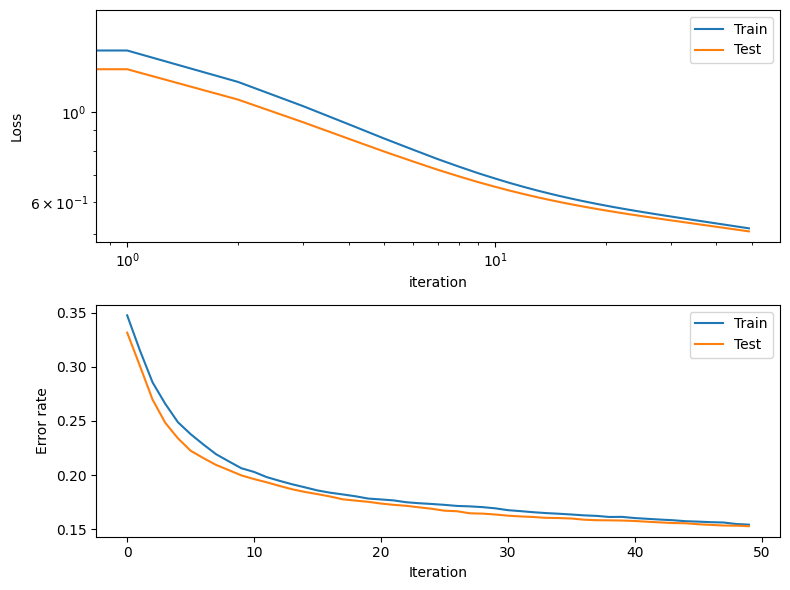

In [ ]:
plt.figure(figsize=(8,6))
plt.subplot(211)

plt.loglog(trainLossTraj, label='Train')
plt.loglog(testLossTraj, label='Test')

plt.ylabel('Loss')
plt.xlabel('iteration')
plt.legend()

plt.subplot(212)

plt.plot(trainErrorTraj, label='Train')
plt.plot(testErrorTraj, label='Test')

#plt.ylim((1e-5,1))
plt.ylabel('Error rate')
plt.xlabel('Iteration')
plt.legend()
plt.tight_layout()

plt.show()

Таким образом, мы смогли уменьшить ошибку классификации в два раза, просто "пошевелив" центры классов.

Посмотрим на примеры новых предсказаний:

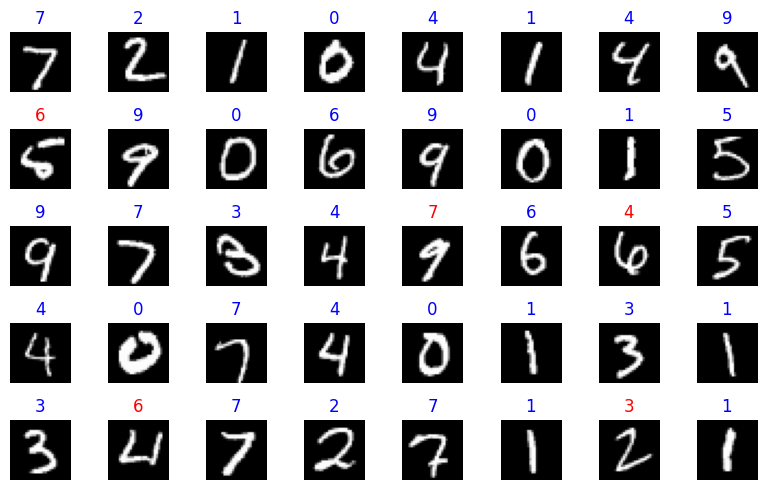

In [ ]:
YtestPred = classifyByCenterDist_Soft(Xtest_t)

plt.figure(figsize=(8,5))
for n in range(40):
    plt.subplot(5,8,n+1)
    plt.imshow(Xtest[n], cmap='gray')
    predClass = int(torch.argmax(YtestPred[n]))
    plt.title(predClass, color=['r','b'][int(predClass==Ytest[n])])
    plt.axis('off')
plt.tight_layout()
plt.show()

Мы видим, что ошибок действительно стало меньше, причем существенная часть из них отвечает ситуациям, в которых написание цифры похоже на другую цифру.

Посмотрим еще на оптимизированные "центры" (центроиды) классов.

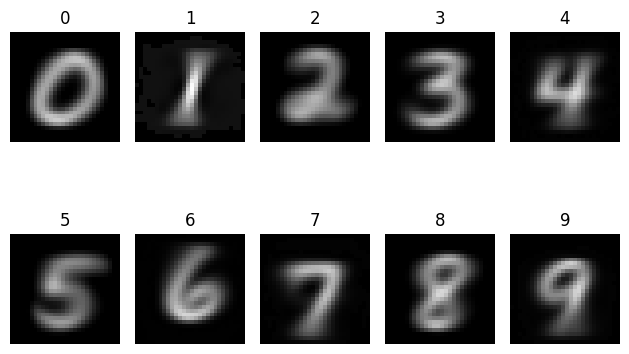

In [ ]:
centersOpt = centers.detach().cpu()

for n in range(10):
    plt.subplot(2,5,n+1)
    center = centersOpt[n]
    plt.imshow(center, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.title(n)
plt.tight_layout()
plt.show()

Визуально они мало отличаются от исходных барицентров, однако при более внимательном сравнении можно увидеть, что отличия все же есть.

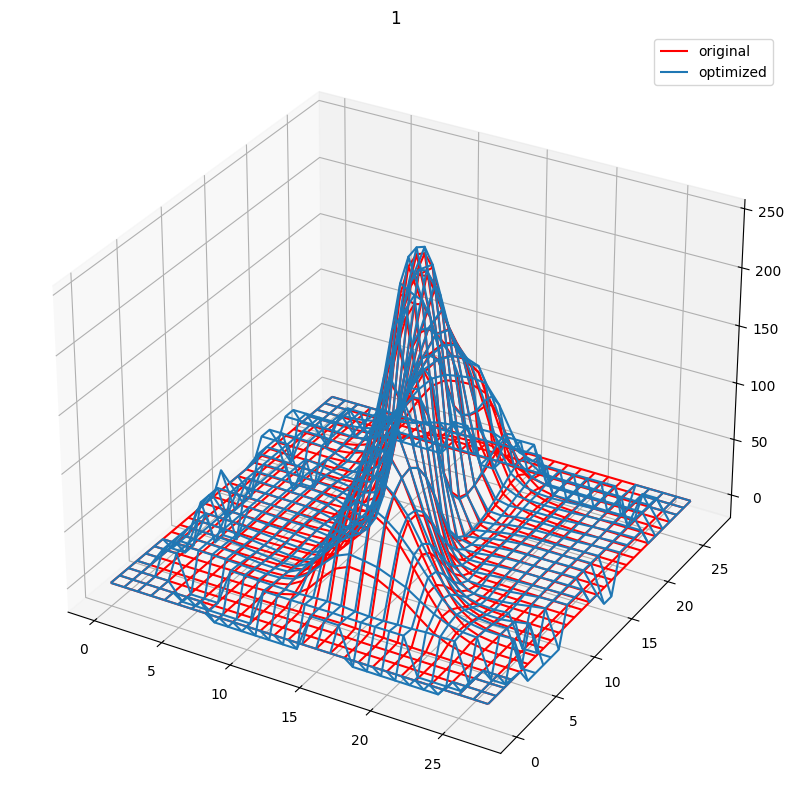

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

X, Y = np.meshgrid(np.arange(Xmean.shape[1]), np.arange(Xmean.shape[2]))


fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

n = 1


surf_orig = ax.plot_wireframe(X, Y, Xmean[n], color='r', alpha=1, label='original') # plot_surface
surf_opt = ax.plot_wireframe(X, Y, centersOpt[n], alpha=1, label='optimized')
plt.title(n)
plt.legend()

plt.show()

**Диаграммы Вороного.** В приведенном примере, кривые для обучающей и тестовой выборки очень близки друг к другу, и мы не наблюдаем никакого переобучения. Это связано с тем, что наша модель довольно простая. Во-первых, она содержит сравнительно небольшое число параметров: $10\cdot 28\cdot 28$ координат центров классов, что намного меньше, например, общего числа $10\cdot 10000$ значений 10 компонент предсказаний на обучающей выборке размера 10000.

Во-вторых, предсказания имеют довольно простую структуру. Пусть $\mathbf x$ - данное изображение цифры, а $\mathbf x_c, \mathbf x_{c'}$ - центры двух классов. Пусть $r$ и $r'$ - обычные евклидовы расстояния от $\mathbf x$ до $\mathbf x_c$ до $\mathbf x_{c'}$:

$$
r = |\mathbf x-\mathbf x_c|=\sqrt{\sum_{i=1}^{28}\sum_{j=1}^{28}(x_{ij}-x_{c; ij})^2},\quad r'= |\mathbf x-\mathbf x_{c'}| = \sqrt{\sum_{i=1}^{28}\sum_{j=1}^{28}(x_{ij}-x_{c'; ij})^2}.
$$

Тогда условие $r<r'$ означает, что точка $\mathbf x$ лежит в полупространстве, образованном гиперплоскостью, разделяющей точки $\mathbf x_c, \mathbf x_{c'}$ и содержащем точку $\mathbf x_c$ (**упражнение!**):

$$ \sum_{i=1}^{28}\sum_{j=1}^{28} x_{ij}(x_{c';ij}-x_{c;ij}) < \sum_{i=1}^{28}\sum_{j=1}^{28} \frac{(x_{c';ij}+x_{c;ij})}{2}(x_{c';ij}-x_{c;ij}).
$$

Отсюда следует, что мы можем геометрически описать множество изображений, классифицируемых нашей моделью как относящихся к классу $c$, как пересечение девяти полупространств, отвечающих сравнениям расстояния до центроида $\mathbf x_{c}$ с расстояниями до всех остальных девяти центроидов. В частности, изображения, классифицируемые моделью как $c$, образуют (неограниченный) полиэдр в $28\cdot 28$-мерном пространстве с не более чем девятью гранями. Все пространство разбивается на такие полиэдры, отвечающие разным классам.

Для иллюстрации этого соображения рассмотрим более простую модель, допускающую двумерную визуализацию. Будем использовать для предсказаний классов не все пиксели картинки, а лишь два (конечно, это ограничение существенно ухудшит точность предсказаний), например с координатами $A = (14, 14)$ и $B = (20, 6)$. Легко убедиться, что даже этих двух пикселей достаточно, чтобы достаточно надежно разделить некоторые классы, например 0 и 1:

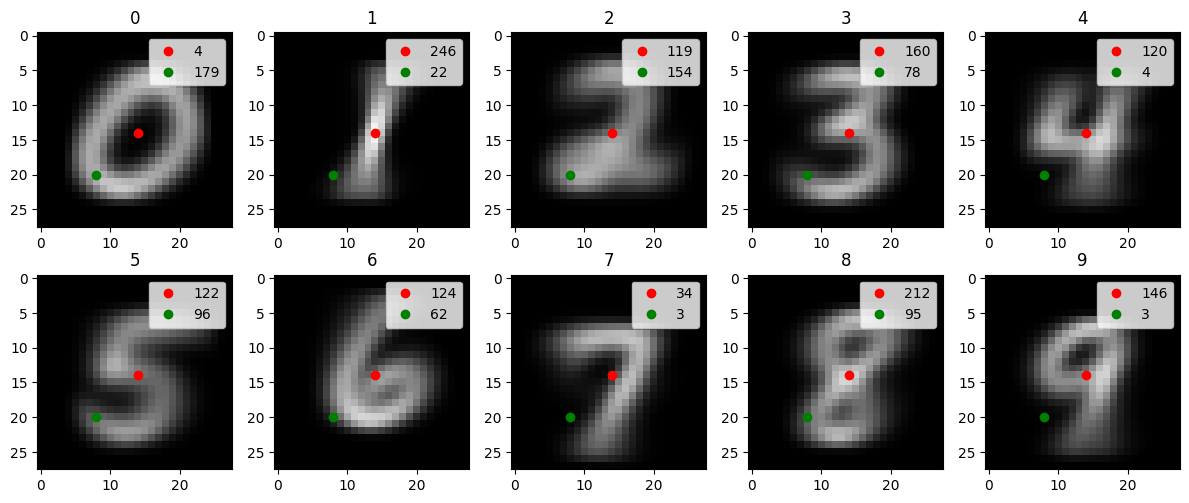

In [ ]:
p0 = [14, 14]
p1 = [20, 8]

plt.figure(figsize=(12,5))
for n in range(10):
    plt.subplot(2,5,n+1)
    plt.imshow(Xmean[n], cmap='gray', vmin=0, vmax=255)
    plt.plot(p0[1], p0[0], 'ro', label= int(Xmean[n, p0[0], p0[1]]))
    plt.plot(p1[1], p1[0], 'go', label= int(Xmean[n, p1[0], p1[1]]))
    #plt.axis('off')
    plt.legend()
    plt.title(n)
plt.tight_layout()
plt.show()

(Легенда показывает среднее значение интенсивности соответствующего пикселя.)

Отберем изображения цифр 0 и 1 среди первых $N$ примеров, и для каждого из них поставим на двумерной плоскости точку, отвечающую интенсивности изображения в этих двух пикселях. Также отметим двумя звездочками соответствующие усредненные значения (барицентры классов 0 и 1).

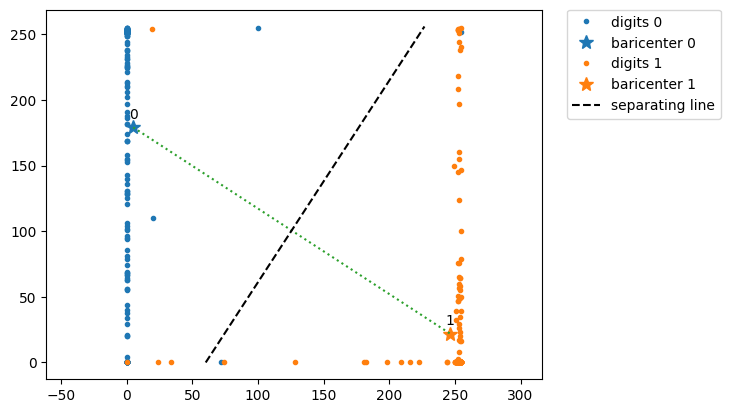

In [ ]:
N = 2000
for c in range(2):
    X = Xtrain[:N][Ytrain[:N]==c]
    line, = plt.plot(X[:, p0[0], p0[1]], X[:, p1[0], p1[1]], '.', label='digits '+str(c))
    plt.plot(Xmean[c, p0[0], p0[1]], Xmean[c, p1[0], p1[1]], '*', ms=10,
             color=line.get_color(), label='baricenter '+str(c))
    plt.text(Xmean[c, p0[0], p0[1]], Xmean[c, p1[0], p1[1]]+7, c, ha='center')

separating_line_center = [0.5*(Xmean[0, p0[0], p0[1]]+Xmean[1, p0[0], p0[1]]),
                          0.5*(Xmean[0, p1[0], p1[1]]+Xmean[1, p1[0], p1[1]])]
separating_line_direction = [Xmean[0, p1[0], p1[1]]-Xmean[1, p1[0], p1[1]],
                             Xmean[1, p0[0], p0[1]]-Xmean[0, p0[0], p0[1]]]
assert separating_line_direction[0] > 0 and separating_line_direction[1] > 0

t_max = np.min([(256-separating_line_center[0])/separating_line_direction[0],
                (256-separating_line_center[1])/separating_line_direction[1]])
t_min = np.max([(-separating_line_center[0])/separating_line_direction[0],
                (-separating_line_center[1])/separating_line_direction[1]])


plt.plot([Xmean[0, p0[0], p0[1]], Xmean[1, p0[0], p0[1]]],
         [Xmean[0, p1[0], p1[1]], Xmean[1, p1[0], p1[1]]],
         ':')

t = np.array([t_min, t_max])
plt.plot(separating_line_center[0]+separating_line_direction[0]*t,
         separating_line_center[1]+separating_line_direction[1]*t,
         'k--', label='separating line')

plt.axis('equal')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

Мы видим, что выбранные нами два признака - интенсивности в точках A и B - действительно группируют точки в две довольно разные группы. Группы хорошо разделяются по признаку расстояния до барицентров классов. В то же время картинка подсказывает, что точность разделения можно еще улучшить, если немного пошевелить эти барицентры.

Построим также соответствующую картинку со всеми 10 классами.

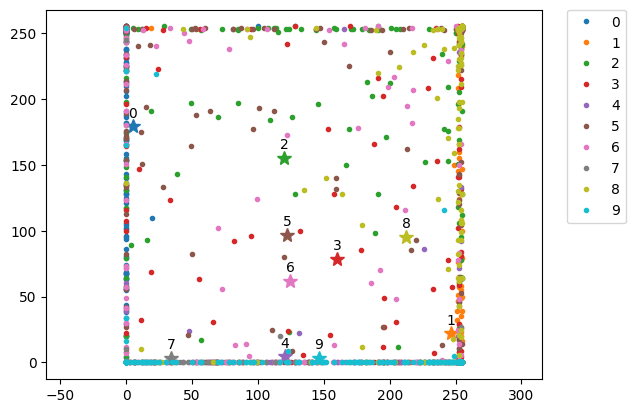

In [ ]:
N = 2000

fig, ax = plt.subplots()
for c in range(10):
    X = Xtrain[:N][Ytrain[:N]==c]
    line, = plt.plot(X[:, p0[0], p0[1]], X[:, p1[0], p1[1]], '.', label=c)
    plt.plot(Xmean[c, p0[0], p0[1]], Xmean[c, p1[0], p1[1]], '*', ms=10, color=line.get_color())
    plt.text(Xmean[c, p0[0], p0[1]], Xmean[c, p1[0], p1[1]]+7, c, ha='center')

plt.axis('equal')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

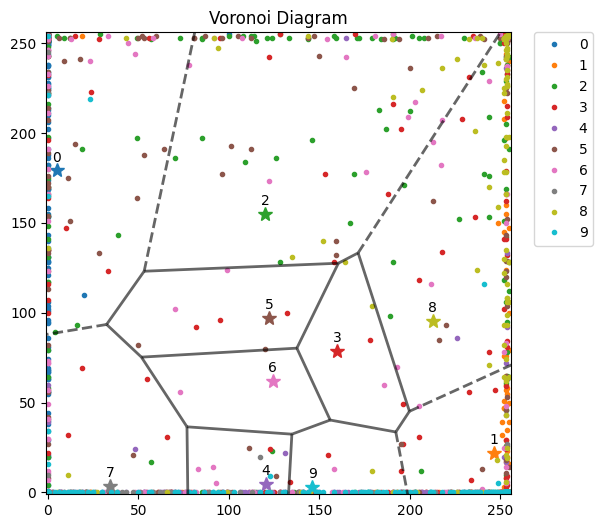

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

vor_points = np.empty((10,2))
vor_points[:,0] = Xmean[:, p0[0], p0[1]]
vor_points[:,1] = Xmean[:, p1[0], p1[1]]

vor = Voronoi(vor_points)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))


for c in range(10):
    X = Xtrain[:N][Ytrain[:N]==c]
    line, = plt.plot(X[:, p0[0], p0[1]], X[:, p1[0], p1[1]], '.', label=c)
    plt.plot(Xmean[c, p0[0], p0[1]], Xmean[c, p1[0], p1[1]], '*', ms=10, color=line.get_color())
    plt.text(Xmean[c, p0[0], p0[1]], Xmean[c, p1[0], p1[1]]+5, c, ha='center')

voronoi_plot_2d(vor, ax=ax, show_vertices=False, #line_colors='k',
                line_width=2, line_alpha=0.6, point_size=0)

ax.set_title('Voronoi Diagram')
plt.xlim([-1,256])
plt.ylim([-1,256])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

Мы получили разбиение плостости на 10 "обобщенных" (вообще говоря, неограниченных) многоугольников, отвечающих разным классам. Каждый многоугольник получен как множество точек, более близких к соответствующему барицентру, чем к любому из остальных 9 барицентров. Разбиения такого вида называются *диаграммами Вороного*.

В отличие от разбиения для 2 классов, мы видим, что эффективность барицентрического разбиения Вороного для 10 классов уже довольно низкая с точки зрения нашей классификационной задачи: внутри почти всех многоугольников имеется много точек разных цветов. Это неудивительно, так как мы пытаемся решить задачу 10-классовой классификации, используя всего лишь два признака (яркость двух фиксированных пикселей). Очевидно, что такой набор признаков слишком беден; данная модель не использует всей имеющейся в данных полезной информации.

**Выразительность модели. Функция XOR.** Отметим, что многоугольники (или многогранники, в случае более высоких размерностей) Вороного являются *выпуклыми*, как пересечения некоторых полуплоскостей (полупространств). Как следствие, даже если оптимизировать положения центроидов классов, наша модель предсказаний на основе сравнения расстояний до центроидов всегда описывает класс как некоторое выпуклое множество. Это накладывает существенное ограничение на ее выразительность. Очевидно, что далеко не все задачи могут быть решены такими моделями.

Классическим примером является реализация функции XOR (*Исключающего ИЛИ*). Пусть $x$ и $y$ - две булевы переменные со значениями "ложь" или "истина" (в числовом представлении, соответственно, 0 или 1). Тогда значение $\operatorname{XOR}(x,y)$ истинно, когда истинно ровно одно из $x$ и $y$.
Геометрически функцию XOR показывает следующий рисунок.



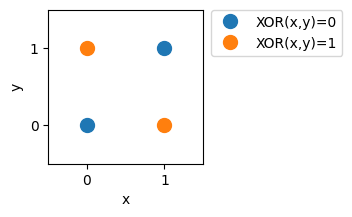

In [ ]:
plt.figure(figsize=(2,2))
plt.plot([0,1], [0,1], 'o', label='XOR(x,y)=0', ms=10)
plt.plot([0,1], [1,0], 'o', label='XOR(x,y)=1', ms=10)

plt.xticks([0,1])
plt.yticks([0,1])
plt.xlim([-0.5,1.5])
plt.ylim([-0.5,1.5])
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

Заметим, что множество "истинных" комбинаций $\{(0,1), (1,0)\}$ нельзя отделить прямой от множества "ложных" комбинаций $\{(0,0), (1,1)\}$. Как следствие, данную классификацию нельзя реализовать методом ближайшего центроида.

К этому же выводу также можно прийти с помощью следующего рассуждения. Как было замечено, метод ближайшего центроида задает каждый класс как выпуклое множество. Если классификатор распознает точки $\{(0,1)\}$ и $\{(1,0)\}$ как принадлежащие одному классу "истина", то и весь соединяющий их отрезок будет классифицироваться как "истина" (внутренние точки отрезка не имеют булевой интерпретации, но ничто не мешает применять к ним наш центроидный классификатор). Аналогично, если классификатор распознает точки $\{(0,0)\}$ и $\{(1,1)\}$ как "ложь", то и весь соединяющий их отрезок будет классифицироваться как "ложь". Однако два указанных отрезка пересекаются, и в точке пересечения мы получаем противоречие.   


### Линейные модели

**Общее понятие.** Метод ближайшего центроида можно рассматривать как частный случай важного типа предсказательных моделей, называемых *линейными*. А именно, линейные модели, в своей базовой форме, имеют вид

$$\mathbf y=W\mathbf x+\mathbf b,$$

где $W$ - некоторая матрица, а $\mathbf b$ - некоторый вектор; это обучаемые параметры модели. Здесь мы интерпретируем векторы $\mathbf x, \mathbf y, \mathbf b$ как векторы-столбцы. Вектор $\mathbf b$ имеет ту же размерность, что и выходной вектор $\mathbf y$. Если $\dim(\mathbf x)=d$, а $\dim(\mathbf y)=m,$ то матрица $W$ имеет размер $m\times d$. В координатном виде линейную модель можно записать как

$$y_i=\sum_{j=1}^d w_{ij}x_j+b_i,\quad i=1,\ldots,m.$$

В случае классификационных задач с бинарным кодированием классов размерность $m$ равна числу классов $C$, а к выходам $y_i$ применяется softmax, так что на выходе мы получаем вектор $\mathbf z$ вероятностей классов:


$$z_c=\frac{e^{y_c}}{\sum_{i=1}^C e^{y_i}},\quad y_i=\sum_{j=1}^d w_{ij}x_j+b_i,\quad c=1,\ldots,С.$$

В случае жесткой классификации предсказываемый класс $c$ отвечает максимальному $y_i$:

$$с=\arg\max_{i=1,\ldots,C} y_i,\quad y_i=\sum_{j=1}^d w_{ij}x_j+b_i.$$

Например, при линейной классификации MNIST имеем $m=C=10$ и $d=28\cdot 28$.

**Пример: метод ближайшего центроида.** Покажем, что классификация рассмотренным ранее методом ближайшего центроида - это фактически линейная модель.

Действительно, квадрат расстояния между заданным вектором $\mathbf x$ и центроидом $\mathbf x_c$ можно записать как

$$(\mathbf x-\mathbf x_c)^T(\mathbf x-\mathbf x_c)=\mathbf x^T\mathbf x-2\mathbf x_c^T\mathbf x+\mathbf x_c^T\mathbf x_c.$$

С точки зрения зависимости от $\mathbf x,$ выражение справа содержит чисто квадратичную часть $\mathbf x^T\mathbf x$, чисто линейную часть $-2\mathbf x_c^T\mathbf x$ и константу $\mathbf x_c^T\mathbf x_c$. Квадратичная часть не зависит от $c$, поэтому не влияет на softmax и argmax; мы можем ее отбросить. Оставшееся выражение $-2\mathbf x_c^T\mathbf x+\mathbf x_c^T\mathbf x_c$ в точности равно компоненте $y_c$ линейной модели, в которой $c$-я строка матрицы $W$ равна $-2\mathbf x_c^T$, а константа $b_c$ равна $\mathbf x_c^T\mathbf x_c$.

> **Упражнение.** Верно ли обратное: каждую ли линейную классификационную модель можно записать в виде модели ближайших расстояний с некоторыми центроидами? (Ответ: нет.)

**Выпуклость и ее следствия.** Важным свойством линейных моделей является выпуклость их стандартных функций потерь. Напомним, что функция нескольких переменный $f:\mathbb R^n\to \mathbb R$ называется *выпуклой*, если для любых $\mathbf x, \mathbf x'\in \mathbb R^n$ и $\lambda\in [0,1]$ выполнено

$$f(\lambda\mathbf x+(1-\lambda)\mathbf x')\le \lambda f(\mathbf x)+(1-\lambda)f(\mathbf x'),$$

то есть график функции лежит не выше отрезка, соединяющего две точки графика.

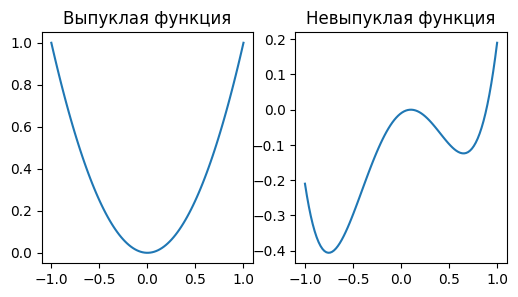

In [ ]:
x = np.linspace(-1,1,100)

plt.figure(figsize=(6,3))
plt.subplot(121)
plt.plot(x, x**2)
plt.title("Выпуклая функция")

plt.subplot(122)
plt.plot(x, x**4-1*(x-0.1)**2)
plt.title("Невыпуклая функция")

plt.show()

> **Упражнение.** Выпуклость функции можно эквивалентно определить как выпуклость, как множества, ее *надграфика* $\{(\mathbf x,y)\in\mathbb R^n\times \mathbb R: f(\mathbf x)\le y\}$.

Приведем набросок рассуждений, показывающих выпуклость стандартных функций потерь линейных моделей.
1. **(Сведение к точечным функциям потерь)** Напомним, что функция потерь модели обычно имеет вид усреднения $L(\mathbf w)=\frac{1}{N}\sum_{n=1}^N \ell(\mathbf x_n, \mathbf y_n, \mathbf w)$ некоторых *точечных* функций потерь $\ell(\mathbf x_n,\mathbf y_n, \mathbf w)$, вычисляемых для разных точек данных $(\mathbf x_n,\mathbf y_n)$. Легко видеть, что если каждая функция $\ell(\mathbf x_n,\mathbf y_n, \mathbf w)$ выпукла по $\mathbf w$, то и функция $L(\mathbf w)$ выпукла. Таким образом, достаточно проверить выпуклость функций $\ell(\mathbf x_n,\mathbf y_n, \mathbf w)$ как функций от $\mathbf w$.
2. **(Сохранение выпуклости при линейных заменах)** Функция $\ell(\mathbf x_n,\mathbf y_n, \mathbf w)$ как правило имеет вид $l(\mathbf y_n, \widehat{\mathbf y}_n),$ где $\mathbf y_n$ - истинное значение,  $\widehat{\mathbf y}_n=f(\mathbf x_n,\mathbf w)$ - результат применения модели к входному вектору $\mathbf x_n$, а $l$ - некоторая сравнивающая их функция. Заметим, что образы выпуклых комбинаций векторов под действием линейных функций $f$ являются выпуклыми комбинациями образов: $f(\lambda \mathbf w+(1-\lambda)\mathbf w')=\lambda f(\mathbf w)+(1-\lambda)f(\mathbf w')$. Отсюда следует, что для проверки выпуклости $\ell(\mathbf x_n,\mathbf y_n, \mathbf w)$ по $\mathbf w$ достаточно проверить выпуклость по $\widehat{\mathbf y}$ функции $l(\mathbf y, \widehat{\mathbf y})$.
3. **(Регрессионные задачи и среднеквадратичная функция потерь)** В случае регрессионных задач и СКО $l(\mathbf y, \widehat{\mathbf y})=|\mathbf y-\widehat{\mathbf y}|^2=\sum_{i=1}^m (y_i-\widehat{y}_i)^2$. Так как сумма выпуклых функций выпукла, достаточно проверить выпуклость функции $g(\widehat y)=(y-\widehat y)^2$ по $\widehat y$. Более того, функция вида $f(y-\widehat y)$ выпукла тогда и только тогда, когла выпукла функция $f(\widehat y),$ поэтому достаточно проверить выпуклость функции $\widehat y^2$. Это совсем просто:   
\
$$\lambda \widehat y^2+(1-\lambda)\widehat y'^2-(\lambda\widehat y+(1-\lambda)\widehat y')^2=\lambda(1-\lambda)(\widehat y'-\widehat y)^2\ge 0,\quad \lambda\in[0,1].$$  

4. **(Классификационные задачи и кроссэнтропийная функция потерь)** В случае классификационных задач и кроссэнтропийной функции потерь ситуация более тонкая. Напомним, что в этом случае точечная функция потерь была определена нами как $-\ln p_{c(\mathbf x)},$ где $c(\mathbf x)$ - истинный класс объекта $\mathbf x,$ а $p_c$ - предсказываемая моделью вероятность класса $c$. Напомним также, что вероятности классов $p_с$ вычисляются из предсказаний $\widehat y_c$ собственно линейной модели с помощью операции softmax:
\
$$p_c=\frac{e^{\widehat y_c}}{\sum_{i=1}^C e^{\widehat y_i}}.$$
\
Поэтому выпуклость функции потерь сводится к выпуклости функции
\
$$\widehat{\mathbf y}\mapsto -\ln\frac{e^{\widehat y_c}}{\sum_{i=1}^C e^{\widehat y_i}}$$
\
при фиксированном $c$. Выпуклость этой функции можно проверить с помощью стандартных неравенств типа неравенства Гельдера или с помощью локального дифференциального критерия.
\
(Во избежание путаницы подчеркнем еще раз, что, в отличие от регрессионных задач, полный линейный классификатор включает как собственно линейные операции, так и нелинейную операцию softmax, необходимую для того, чтобы его результат можно было интерпретировать как распределение вероятностей. Свойство линейности модели относится лишь к зависимости $\widehat{\mathbf y}$ от $\mathbf x$ и $\mathbf w$.)

Теперь поясним, почему выпуклость функции потерь важна.

1. **(Глобальность локальных минимумов)** Часто полезно разделять *глобальные* и *локальные* минимумы функции. Предполагая, что функция $L$ определена на $\mathbb R^n$, точка $\mathbf w_*$ называется *глобальным* минимумом функции $L(\mathbf w),$ если $L(\mathbf w_*)\le L(\mathbf w')$ для всех точек $\mathbf w'\in \mathbb R^n$. Точка $\mathbf w_*$ называется *локальным* минимумом функции $L(\mathbf w),$ если $L(\mathbf w_*)\le L(\mathbf w')$ для всех точек $\mathbf w'$ из некоторого шара с центром в $\mathbf w_*$. Любой глобальный минимум является и локальным, однако обратное вообще говоря не верно. Однако для выпуклых функций $L$ верно и обратное.
\
Действительно, пусть точка $\mathbf w$ не является глобальным минимумом выпуклой функции $L$. Тогда найдется точка $\mathbf w'$ такая, что $L(\mathbf w') < L(\mathbf w)$. Из выпуклости функции $L$ тогда следует, что при любом $\lambda\in[0,1)$   
\
$$L(\lambda\mathbf w+(1-\lambda)\mathbf w')\le \lambda L(\mathbf w)+(1-\lambda)L(\mathbf w') < L(\mathbf w),$$
\
то есть в любой точке отрезка, соединяющего $\mathbf w$ и $\mathbf w'$, отличной от $\mathbf w$, значение функции $L$ строго меньше, чем в точке  $\mathbf w$. Следовательно, $\mathbf w$ не может быть локальным минимумом.
\
Таким образом, в случае выпуклых функций локальные минимумы совпадают с глобальными.
2. **(Выпуклость множества минимумов)** Из определения выпуклости функции немедленно следует, что если в точках $\mathbf w$ и $\mathbf w'$ достигается минимум функции потерь, то он достигается и в любой точке отрезка, соединяющего $\mathbf w$ и $\mathbf w'$. Иными словами, множество минимумов также выпукло. В частности, оно *связно*.
3. **(Дифференциальный критерий минимума)** Если функция $L(\mathbf w)$ дифференцируема, то необходимым условием достижения минимума в точке $\mathbf w_*$ является $\nabla L(\mathbf w_*)=0$. В случае выпуклых функций это условие является также и достаточным.
4. **(Сходимость градиентного спуска)** При некоторых естественных дополнительных предположениях (выполняющихся, например, для линейных моделей и СКО) можно показать, что градиентный спуск порождает последовательность точек $\mathbf w_k$, в которых функция потерь гарантированно сходится к минимуму: $\lim_{k\to\infty}L(\mathbf w_k)=\min_{\mathbf w\in\mathbb R^n}L(\mathbf w)$.

Забегая вперед, отметим, что эти свойства не выполняются, вообще говоря, в более сложных моделях (например, нейронных сетях). Например, градиентный спуск может "застревать" в локальных минимумах, не доходя до оптимального решения задачи.


**Метод наименьших квадратов и аналитическое решение.** Еще одним важным свойством линейных моделей является наличие у них *аналитического решения*. А именно, оптимальные по отношению к *среднеквадратичной функции потерь* параметры модели (матрицу $W$ и вектор $\mathbf b$) можно выразить явной аналитической формулой, использующей стандартные матричные операции.

Приведем набросок вывода. Заметим, что формулу действия модели $\mathbf y=W\mathbf x+\mathbf b$ можно упростить следующим образом. Заменим входные векторы $\mathbf x$ на "расширенные" векторы $\widetilde{\mathbf x}=\begin{pmatrix}\mathbf x\\ 1\end{pmatrix}$ с добавленной компонентой, равной 1. Тогда действие модели можно записать как $\mathbf y=\widetilde{W}\widetilde{\mathbf{x}}$. Поэтому будем просто считать без ограничения общности, что модель имеет вид $\mathbf y={W}{\mathbf{x}}$.

Напомним, что в случае моделей со скалярным выходом мы определили  среднеквадратичную функцию потерь как

$$L_2(\mathbf w)=\frac{1}{N}\sum_{n=1}^N(f(\mathbf x_n,\mathbf w)-y_n)^2.$$

Здесь $f(\mathbf x_n,\mathbf w)$ - результат применения модели к $n$-му объекту $\mathbf x_n$, а $y_n$ - истинное значение, с которым сравнивается наше предсказание. В случае векторнозначной модели $\mathbf f$ ее СКО можно определить просто как сумму СКО всех скалярных компонент выхода, что в векторном виде можно записать как

$$L_2(\mathbf w)=\frac{1}{N}\sum_{n=1}^N|\mathbf {f}(\mathbf x_n,\mathbf w)-\mathbf {y}_n|^2,$$

где $|\cdot|$ обозначает евклидову длину.
В нашем случае вектор обучаемых параметров $\mathbf w$  отвечает матрице $W$, так что функция потерь имеет вид

$$L_2(W)=\frac{1}{N}\sum_{n=1}^N|W\mathbf x_n-\mathbf {y}_n|^2.$$

Как отмечено ранее, необходимым и достаточным условием минимума функции потерь является $\nabla L(\mathbf w)=0$. Прямое вычисление показывает (**упражнение**), что

$$\nabla L_2(W)=\frac{2}{N}\sum_{n=1}^N(W \mathbf x_n-\mathbf y_n)\mathbf x_n^T=\frac{2}{N}(W X-Y)X^T,$$

где $X$ - матрица размера $d\times N$, составленная из $N$ векторов-столбцов $\mathbf x_n$, а $Y$ - матрица размера $m\times N$, составленная из $N$ соответствующих векторов-столбцов $\mathbf y_n$. Приравнивая градиент нулю и предполагая невырожденность матрицы $XX^T,$ получаем, что оптимальная матрица весов имеет вид

$$W=YX^T(XX^T)^{-1}.$$

Таким образом, в случае среднеквадратичной функции потерь оптимальные параметры линейной модели в принципе выражаются с помощью явной аналитической формулы. (Отметим, однако, что в реальных достаточно больших задачах эта формула - в отличие от градиентного спуска! - малоприменима для непосредственного нахождения оптимальных моделей из-за большого размера матриц и быстрого накопления численной погрешности.)

**Регуляризация.** Полученная формула $W=YX^T(XX^T)^{-1}$ подразумевает невырожденность матрицы $XX^T$. Так как столбцы этой матрицы отвечают $N$ векторам $\mathbf x_n$ обучающей выборки, невырожденность требует, как минимум, чтобы $N$ было не меньше размерности $d$ векторов $\mathbf x_n$. На практике, даже если $N\gg d$, матрица $XX^T$ часто оказывается близка к вырожденной (как говорят, *плохообусловленной*). По этой причине часто удобно рассматривать *регуляризованную* матрицу $XX^T+\lambda I_{d\times d},$ где $\lambda>0$ - некоторый параметр регуляризации. Такая матрица обратима даже если $N<d$. Регуляризованная формула для весов тогда принимает вид

$$W=YX^T(XX^T+\lambda I_{d\times d})^{-1}.$$

Увеличение $\lambda$ усиливает искажение решения, но улучшает его устойчивость (в частности, по отношению к погрешностям численных рассчетов на компьютере).  

**Двойственное представление.** Иногда (например, в затрагиваемой ниже теории ядерных методов) удобно использовать *двойственное* (или *дуальное*) представление для оптимальных весов. Для этого удобно использовать введенное выше регуляризованное представление. Заметим, что при любом $\lambda > 0$ имеет место тождество

$$X^T(XX^T+\lambda I_{d\times d})^{-1}=(X^TX+\lambda I_{N\times N})^{-1}X^T.$$

Действительно, для доказательства достаточно заметить, что

$$(X^TX+\lambda I_{N\times N})X^T=X^T XX^T+\lambda X^T=X^T(XX^T+\lambda I_{d\times d}).$$

Умножая это равенство слева на $(X^TX+\lambda I_{N\times N})^{-1}$ и справа на $(XX^T+\lambda I_{d\times d})^{-1}$, получаем требуемое тождество.

С учетом данного тождества регуляризованную формулу весов можно записать в виде

$$W=Y(X^TX+\lambda I_{N\times N})^{-1}X^T.$$

Подставляя в формулу модели $\mathbf y=W\mathbf x$, получаем полную формулу прогноза

$$\mathbf y=Y(X^TX+\lambda I_{N\times N})^{-1}X^T\mathbf x.$$

Отметим, что матрица $X^T X$, фигурирующая в данном дуальном представлении, фактически представляет собой матрицу Грама системы векторов $(\mathbf x_n)_{n=1}^N,$ то есть составлена из $N^2$ скалярных произведений $(\mathbf x_n^T \mathbf x_m)_{n,m=1}^N$. Произведение $X^T\mathbf x$ является вектором-столбцом, составленным из $N$ скалярных произведений $(\mathbf x_n^T \mathbf x)_{n=1}^N$. Таким образом, предсказание регуляризованной линейной модели зависит от входных частей обучающих примеров $\mathbf x_n$ и данного входа $\mathbf x$ лишь через их попарные скалярные произведения. Это обстоятельство будет играть важную роль далее для теории ядерных моделей.     

**Ограниченная выразительность, два вида линейности, нелинейные признаки.** Как и рассмотренная ранее модель ближайших соседей, общие линейные модели имеют очень ограниченную выразительность. В частности, множество точек $\mathbf x$, относимых линейной классификационной моделью к определенному классу $c$, всегда является выпуклым многогранником (**упражнение**). Как следствие, такие модели неспособны решать задачи типа XOR.

Отметим, однако, следующее важное соображение. Говоря о линейных моделях, важно различать линейную зависимость выхода модели от параметров $\mathbf w$ и от входного вектора $\mathbf x$. Выражение $y_i=\sum_{j=1}^d W_{ij}x_j+b_i$, использовавшееся нами в определении линейной модели, линейно и в том, и в другом смысле. Однако мы можем рассмотреть и модели, в который линейность присутствует только по отношению к одной из этих двух групп переменных. В частности, мы можем представить, что модель имеет вид  

$$y_i=\sum_{j=1}^h W_{ij}\phi_j(\mathbf x)+b_i$$

с некоторыми, вообще говоря, нелинейными функциями $\phi_j(\mathbf x)$. Это выражение линейно по параметрам $W_{ij}$ и $b_i$, но не по входным переменным $x_i$. Количество $h$ функций $\phi_j(\mathbf x)$ может отличаться от размерности $d$ вектора $\mathbf x$ (более того, эта формула применима даже если $\mathbf x$ не является вектором). Функции $\phi_i$ часто называют *признаками* (features). Указанную обобщенную модель можно интерпретировать как линейную, но использующую новое, признаковое описание объектов в виде векторов $(\phi_1(\mathbf x),\ldots,\phi_{h}(\mathbf x))$ вместо исходного описания в виде $(x_1,\ldots,x_d)$.   

Мы указали ранее на достоинства линейных моделей, связанные с выпуклостью (идентичность локальных и глобальных минимумов, эквивалентность минимальности условию $\nabla L=0$, гарантии сходимости градиентного спуска). Все эти достоинства сохраняются у линейных моделей с произвольными фиксированными признаковыми функциями $\phi_j$. В обсуждении выпуклости для нас была важна линейность лишь по параметрам $\mathbf w$, но не по входам $\mathbf x$.  

С другой стороны, замена исходных координат новыми признаками может решить проблему низкой выразительности линейной модели. Точки, относимые к определенному классу $c$, теперь образуют выпуклые многогранники в признаковом пространстве, а не в пространстве исходных векторов $\mathbf x$. Для достаточно богатых семейств признаков можно ожидать, что соответствующие семейства множеств в пространстве исходных векторов будут гораздо более гибкими. Именно на этом основана идея *ядерных линейных моделей*.  

**Ядерные линейные модели. "Ядерный трюк".**  Напомним, полученное ранее выражение для предсказаний линейной модели в дуальном представлении:

$$\mathbf y=Y(X^TX+\lambda I_{N\times N})^{-1}X^T\mathbf x.$$

Если вместо исходного представления $\mathbf x=(x_1,\ldots,x_d)$ векторов данных использовать признаковое описание $\mathbf z = (\phi_1(\mathbf x),\ldots,\phi_{h}(\mathbf x))$, то модель имеет аналогичную структуру, но с матрицей $Z$ признаков обучающих данных вместо $X$:

$$\mathbf y=Y(Z^TZ+\lambda I_{N\times N})^{-1}Z^T\mathbf z,$$

где $Z_{in}=\phi_i(\mathbf x_n)$. Введем функцию $k(\mathbf x, \mathbf x')$, называемую *ядром*:

$$k(\mathbf x,\mathbf x')=\sum_{i=1}^h \phi_i(\mathbf x)\phi_i(\mathbf x')=\boldsymbol\phi(\mathbf x)^T\boldsymbol\phi(\mathbf x'),$$

где $\boldsymbol\phi(\mathbf x)=(\phi_1(\mathbf x),\ldots,\phi_h(\mathbf x))^T$ - вектор признаков в точке $\mathbf x$. Заметим, что предсказание нашей признаковой линейной модели в точке $\mathbf x$ теперь можно записать в матричной форме

$$\mathbf y=Y(K+\lambda I_{N\times N})^{-1}\mathbf k,$$

с матрицей

$$K=(k(\mathbf x_m,\mathbf x_n))_{m.n=1}^N$$

и вектор-столбцом

$$\mathbf k=(k(\mathbf x_m,\mathbf x))_{m=1}^N.$$

Таким образом, для использования нашей модели нам достаточно знать только функцию $k(\mathbf x,\mathbf x')$, а не полное признаковое описание $\boldsymbol\phi(\mathbf x)$ векторов $\mathbf x$. Это наблюдение известно как "ядерный трюк", и оно довольно важно, так как и структура модели упрощается, и ядра $k(\mathbf x,\mathbf x')$ во многих случаях устроены сравнительно просто. Например, наиболее популярное в приложениях гауссовское ядро имеет вид

$$k(\mathbf x,\mathbf x')=e^{-\theta|\mathbf x-\mathbf x'|^2}$$

с некоторым фиксированным параметром ширины $\theta$.

**Альтернативный вывод формулы ядерной модели.** Покажем, что формулу ядерной модели без регуляризации можно получить и по-другому, просто предполагая определенную параметрическую форму модели и находя параметры из условия согласия с обучающими данными. Зафиксируем ядро $k(\mathbf x,\mathbf x')$. Для заданной обучающей выборки $(\mathbf x_n,\mathbf y_n)_{n=1}^N$ будем искать зависимость $\mathbf y(\mathbf x)$ в виде линейной комбинации функций $k(\mathbf x_n,\mathbf x).$ А именно, будем считать, что $i$-я компонента выхода модели имеет вид

$$y_i(\mathbf x)=\sum_{n=1}^N C_{in} k(\mathbf x_n,\mathbf x)=(C\mathbf k)_i,$$

где $C=(C_{in})$ - некоторая матрица коэффициентов размера $m\times N$.

Наложим условия *интерполяции*: в точках обучающей выборки $\mathbf y(\mathbf x_j)=\mathbf y_j,$  то есть для каждой скалярной компоненты $i=1,\ldots, m$ и номера вектора $j=1,\ldots,N$

$$\sum_{n=1}^N C_{in} k(\mathbf x_n,\mathbf x_j)=Y_{ij}.$$

Для каждого фиксированного $i$ эти условия образуют замкнутую линейную систему из $N$ уравнений (отвечающих разным $j$)  с $N$ неизвестными $C_{in}, n=1,\ldots, N$. Общее решение всех уравнений можно записать с помощью введенных ранее матриц $Y, K$ как  

$$C=Y K^{-1}.$$

С использованием ранее введенного вектора $\mathbf k$ формула модели тогда принимает матричный вид

$$\mathbf y(\mathbf x)=C\mathbf k=Y K^{-1}\mathbf k,$$

совпадающий с ранее найденной формулой в случае отсутствия регуляризации (т.е. при $\lambda=0$).

**Положительная определенность ядра.** Ядро $k(\mathbf x,\mathbf x')$ возникло у нас как скалярное произведение признаковых векторов $\boldsymbol{\phi}(\mathbf x)$ и $\boldsymbol{\phi}(\mathbf x')$. Естественно поставить следующий вопрос: какие функции $k(\mathbf x,\mathbf x')$ являются ядрами, то есть порождаются скалярными произведениями некоторых признаковых векторов? Очевидно, во-первых, что функция $k(\mathbf x,\mathbf x')$ должна быть симметричной: $k(\mathbf x,\mathbf x')=k(\mathbf x',\mathbf x)$. Более того, она должна быть *неотрицательно определенной*, в том смысле что для любого конечного набора точек $\mathbf x_1,\ldots,\mathbf x_N$ матрица $K=(k(\mathbf x_i,\mathbf x_j))_{i,j=1}^N$ неотрицательно определена как матрица Грама семейства векторов; то есть для любых $a_1,\ldots,a_N\in\mathbb R$ должно выполняться

$$\sum_{i,j=1}^N a_ia_jk(\mathbf x_i,\mathbf x_j)\ge 0$$

ввиду представления

$$\sum_{i,j=1}^N a_ia_jk(\mathbf x_i,\mathbf x_j)=\sum_{i,j=1}^N a_ia_j \boldsymbol \phi(\mathbf x)^T\boldsymbol \phi(\mathbf x')= \Big(\sum_{i=1}^N a_i  \boldsymbol \phi(\mathbf x)\Big)^T \Big(\sum_{i=1}^N a_i  \boldsymbol \phi(\mathbf x)\Big)\ge 0.$$

Можно показать, что симметричность и неотрицательная определенность функции $k(\mathbf x,\mathbf x')$ являются и *достаточными* условиями существования некоторого семейства признаковых векторов $\boldsymbol{\phi}(\mathbf x)$, скалярные произведения которых порождают функцию $k(\mathbf x,\mathbf x')$. (Заметим, однако, что соответствующие векторы, вообще говоря, бесконечномерны.)

Благодаря положительной определенности ядра матрица $K+\lambda I_{N\times N}$ строго положительно определена и следовательно обратима при всех $\lambda > 0$. Таким образом, использующие данные обращения ругуляризованные ядерные модели всегда корректно определены. В случае $\lambda=0$ матрица $K$ может быть, вообще говоря, необратима. Однако можно показать, что многие стандартные ядра являются *строго* положительно определенными, в том смысле что для  любого набора попарно различающихся точек $\mathbf x_1,\ldots,\mathbf x_N$ и любого набора чисел $a_1,\ldots,a_N,$ не все из которых равны нулю, выполняется строгое неравенство

$$\sum_{i,j=1}^N a_ia_jk(\mathbf x_i,\mathbf x_j) > 0.$$

В этом случае матрица $K$ обратима и ядерная модель теоретически корректно определена даже без регуляризации.

Заметим также, что, как показано выше, нерегуляризованную ядерную модель можно определить как линейную комбинацию $f(\mathbf x)=\sum_{i=1}^Na_i k(\mathbf x_i,\mathbf x)$ базисных функций  $k(\mathbf x_i,\cdot)$, в которой коэффициенты $a_i $ находятся из условия интерполяции данных в точках $\mathbf x_1,\ldots,\mathbf x_N$. В принципе, вместо базисных функций  $k(\mathbf x_n,\cdot)$ мы могли бы рассмотреть любые другие функции. Однако, вообще говоря, соответствующая система линейных уравнений на коэффициенты может не иметь решения или же иметь очень неустойчивое решение (если соответствующая матрица вырождена или близка к вырождению). В этом отношении ядерные модели, с их гарантиями разрешимости, образуют удобный подкласс моделей такого вида.

**Универсальная выразительность.** Как показано выше, в случае строго положительно определенного ядра и любой обучающей выборки с попарно различными точками $\mathbf x_i$, ядерная модель без регуляризации в точности интерполирует обучающие данные; то есть, ядерные модели в принципе могут реализовать любую функцию, заданную на конечном множестве. Это показывает, что ядерные модели кардинально выразительнее линейных моделей, которые, как мы видели, неспособны выразить даже простые функции типа заданной в 4 точках функции XOR.     


**Нейронные сети.** Ядерные модели и тесно связанные с ними методы (например, машины на опорных векторах - SVM - Support Vector Machines) играли и продолжают играть важную роль в машинном обучении. Изложенные выше элементы теории показывают, что эти модели обладают многими важными и полезными свойствами (в частности, универсальная выразительность, наличие явных аналитических решений, глобальность минимумов и гарантии сходимости градиентного спуска). Однако практика машинного обучения показала, что эти модели недостаточно эффективны для многих реальных задач. Во многих случаях эффективное решение задачи требует у модели наличия определенной структуры, что плохо сочетается с принципиальной простотой линейных и ядерных моделей. По этой причине основными моделями машинного обучения в последнее время стали *нейронные сети*, благодаря их гораздо большей структурной гибкости. Важным аспектом нейронных сетей является их *глубина* (или *многослойность*). В следующем разделе мы рассмотрим *однослойные* нейронные сети, которые очень похожи на ядерные модели, а затем рассмотрим общие многослойные.   

### Нейронные сети с одним скрытым слоем

**Мотивация и общая структора.** Нейронные сети с одним скрытым слоем можно рассматривать как некоторое обобщение линейной модели, очень похожее на ядерную модель. Напомним, что линейная модель с $d$ скалярными входами и $m$ выходами имеет вид

$$y_i=\sum_{j=1}^d w_{ij}x_j+b_i,\quad i=1,\ldots,m.$$

Удобно изобразить такую модель графом, в которой есть $d$ "входных" вершин, $m$ "выходных" вершин, и $md$ ребер, соединяющих входные вершины с выходными. Например, в случае $d=4, m=3$ граф выглядит так:

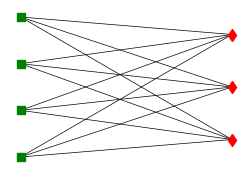

In [ ]:
Ninputs = 4
Noutputs = 3
inputs = np.linspace(start=-Ninputs, stop=Ninputs, num=Ninputs, endpoint=True)
outputs = np.linspace(start=-Noutputs, stop=Noutputs, num=Noutputs, endpoint=True)

plt.figure(figsize=(3,2))

for i in inputs:
    for j in outputs:
        plt.plot([0,1], [i,j], 'k', lw=0.5)

plt.plot(np.zeros(Ninputs), inputs, 'sg')
plt.plot(np.ones(Noutputs), outputs, 'dr')

plt.axis('off')

plt.show()

Мы интерпретируем этот граф как сеть, по которой распространяется информация (или, как еще говорят, сигнал). Исходные данные $x_j$ поступают во входные вершины. Далее они проходят по ребрам графа, умножаясь при этом на соответствующие им веса  $w_{ij}$. В выходных вершинах сигналы от разных входных вершин собираются и суммируются; также к ним прибавляются веса $b_i$. В частности, мы можем сказать, что параметры модели приписаны ребрам ($w_{ij}$) и выходным вершинам ($b_i$).

Однослойная нейронная сеть получается из линейной модели путем добавления дополнительного слоя "скрытых нейронов", вычисляющих некоторую "функцию активации" $\sigma:\mathbb R\to\mathbb R$. В формульном виде однослойная нейронная сеть записывается как

$$y_i=\sum_{j=1}^d w_{ij}^{(2)}\sigma\Big(\sum_{r=1}^h w_{jr}^{(1)}x_r+b_j^{(1)}\Big)+b^{(2)}_i,\quad i=1,\ldots,m,$$

где $h$ - число добавленных скрытых нейронов (это число обычно называют *шириной слоя*). Графически сеть изображается так (здесь $h=6$):

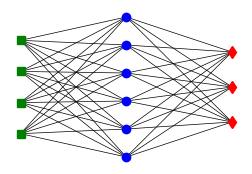

In [ ]:
Ninputs = 4
Noutputs = 3
Nhidden = 6

inputs = np.linspace(start=-Ninputs, stop=Ninputs, num=Ninputs, endpoint=True)
outputs = np.linspace(start=-Noutputs, stop=Noutputs, num=Noutputs, endpoint=True)
hidden = np.linspace(start=-Nhidden, stop=Nhidden, num=Nhidden, endpoint=True)

plt.figure(figsize=(3,2))

for i in inputs:
    for j in hidden:
        plt.plot([0, 0.5], [i,j], 'k', lw=0.5)

for i in hidden:
    for j in outputs:
        plt.plot([0.5, 1], [i,j], 'k', lw=0.5)

plt.plot(np.zeros(Ninputs), inputs, 'sg')
plt.plot(0.5*np.ones(Nhidden), hidden, 'ob')
plt.plot(np.ones(Noutputs), outputs, 'dr')

plt.axis('off')

plt.show()

Сеть содержит два слоя линейных операций (первый задается весами $w_{jr}^{(1)},b_j^{(1)},$ второй - весами $w_{ij}^{(2)},b_i^{(2)}$) но только один слой вычислений активаций $\sigma$, поэтому обычно такую сеть называют однослойной. Интерпретация графа с точки зрения распространения информации аналогична указанной ранее для линейной модели, с той разницей что новые узлы (*нейроны*) не только формируют сумму входных сигналов, но и применяют к ней функцию активации. Иногда нейроны с функцией активацией называют "скрытыми" (показаны кружками), а входные и выходные узлы модели также называют "нейронами", но, соответственно, "входными" и "выходными". Входные нейроны не выполняют никаких операций, а выходные выполняют лишь линейные операции.  

**Функции активации.** Имеется близкая, но все же ограниченная аналогия между реальными биологическими нейронами и нейронами - элементами искусственной нейронной сети. Реальные нейроны передают друг другу электрические импульсы. Если нейрон получает на вход один или несколько импульсов, то он может "активироваться" и в свою очередь также "выстрелить" импульсом. Исходя из этой аналогии, наиболее популярными функциями активации в искусственных нейронных сетях долгое время были так называемые "сигмоидные" функции активации $\sigma:\mathbb R\to\mathbb R$, а именно обладающие двумя свойствами:

1. функция $\sigma$ монотонно возрастает на $\mathbb R$;
2. функция $\sigma$ имеет конечный левый предел $\lim_{x\to -\infty}\sigma(x)$ и конечный правый предел $\lim_{x\to +\infty}\sigma(x)$.

Основным примером функций такого типа является т.н. "стандартная сигмоида"

$$\sigma(x)=\frac{e^x}{1+e^x}.$$



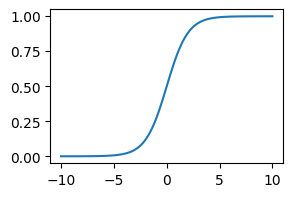

In [ ]:
x = np.linspace(-10,10,100)

plt.figure(figsize=(3,2))
plt.plot(x, np.exp(x)/(1+np.exp(x)))

plt.show()

Однако логика использования функций активации в нейронной сети как  предсказательной модели не определяется биологией реального нейрона. Свойства монотонности и наличия конечных пределов не имеют принципиального характера для нейросетевых вычислений. Наличие конечных пределов может даже вредить ввиду того, что при больших значениях аргумента, когда функция становится примерно постоянной, ухудшается ее чувствительность к изменениям аргумента, что затрудняет градиентный спуск. С другой стороны, с учетом больших размеров современных нейронных сетей, очевидно немаловажным свойством является вычислительная простота функции активации. Примером простой, но очень популярной и вполне практичной функции активации является ReLU (Rectified Linear Unit):

$$\sigma(x)=\max(x,0).$$



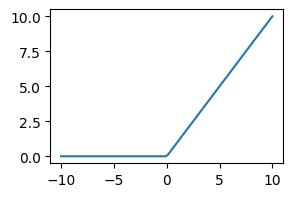

In [ ]:
x = np.linspace(-10,10,100)

plt.figure(figsize=(3,2))
plt.plot(x, np.maximum(x,0))

plt.show()

**Связь с ядерными моделями. "Извлечение признаков."**

Если все веса первого слоя, $w_{jr}^{(1)}$ и $b_j^{(1)}$, зафиксированы и подгоняются лишь веса второго слоя, то нейронная сеть становится линейной моделью по отношению к признакам, вычисляемым скрытыми нейронами:

$$y_i=\sum_{j=1}^h w_{ij}^{(2)}\phi_j(\mathbf x)+b_i^{(2)},\quad \phi_j(\mathbf x)=\sigma\Big(\sum_{r=1}^h w_{jr}^{(1)}x_r+b_j^{(1)}\Big).$$

Таким образом, нейронная сеть фактически является специальным случаем расмотренной ранее линейной ядерной модели. Соответствующее ядро имеет вид

$$k(\mathbf x,\mathbf x')=\sum_{j=1}^h \sigma\Big(\sum_{r=1}^h w_{jr}^{(1)}x_r+b_j^{(1)}\Big)\sigma\Big(\sum_{r=1}^h w_{jr}^{(1)}x'_r+b_j^{(1)}\Big).$$

Все указанные ранее общие свойства ядерных линейных моделей переносятся на нейронную сеть с фиксированным первым слоем, в частности:

1. Стандартные функции потерь (СКО, кросс-энтропийная) выпуклы по весам второго слоя. Их локальные минимумы являются также глобальными. В случае СКО градиентный спуск с достаточно малым параметром шага гарантированно сходится к минимуму.

2. В случае функции потерь СКО для оптимальных значений весов второго слоя имеется явная аналитическая формула.

Ключевое отличие полноценной нейронной сети от ядерной модели заключается, однако, в том, что в ней подгоняются веса обоих слоев. Такая модель уже не является линейной, и указанные выше свойства в ней, вообще говоря, не выполняются: функция потерь не выпукла, локальные минимумы не глобальны, нет явной формулы для оптимальных весов. Но при этом модель приобретает важную способность *извлечения признаков* (feature extraction). Действительно, изложенная ранее теория ядерных моделей подразумавала, что мы заранее каким-то (неизвестным) образом выбрали и зафиксировали признаки $\phi_j(\mathbf x)$. Оптимизация же весов первого слоя нейронной сети фактически производит адаптацию признаков (в рамках определенного класса, а именно композиций функции активации и линейных функций) к данной задаче.    

**Выразительность на конечном множестве входных векторов. Полиномиальные функции активации.**

Так же как и ядерные модели, однослойные нейронные сети преодолевают проблему ограниченной выразительности линейных моделей; при этом (вполне ожидаемо) выразительность напрямую зависит от числа скрытых нейронов.

Приведем сначала некоторые соображения, рассматривая нейронную сеть как ядерную модель (с адаптивным ядром). Предположим, что мы хотим подогнать нейронную сеть к обучающей выборке из $N$ элементов $(\mathbf x_i,\mathbf y_i)_{i=1}^N$ с различными $\mathbf x_i$. Как мы показали ранее, ядерная модель может осуществлять точную итерполяцию любых значений $\mathbf y_i$ в случае невырожденности ядерной матрицы $K=(k(\mathbf x_i,\mathbf x_j))_{i,j=1}^N$ - матрицы Грама системы признаковых векторов $(\boldsymbol\phi(\mathbf x_i))_{i=1}^N$. Если признаковые векторы имеют конечную размерность $h$, то матрица Грама заведомо вырождена при $N>h$, но может быть невырождена (или вырождена) при $N\le h$. Вырожденность означает, что размерность порожденного признаковыми векторами пространства меньше $N$ и, как следствие, найдутся наборы откликов $(\mathbf y_i)_{i=1}^N$, которые не могут в точности воспроизводиться моделью.  В нашем случае $h$ -  число нейронов. Адаптивность признаков в ходе обучения первого слоя позволяет менять пространство признаковых векторов, но при любом их доступном выборе размерность этого пространства ограничена значением $h$. Эти рассуждения показывают, что даже с учетом адаптивности признаков точное решение задачи интерполяции на $N$ точках требует, вообще говоря, $h\ge N$ скрытых нейронов.   

При неудачном выборе функции активации нейронная сеть может иметь ограниченную выразительность даже при растущем числе нейронов. А именно, предположим, что функция активации линейна: $\sigma(x)=ax+b$. Тогда реализуемая моделью функция $\mathbf y(\mathbf x)$ также линейна, то есть добавление скрытого слоя нейронов вообще никак не увеличивает выразительность модели.

Сделаем теперь более широкое предположение: пусть функция активации $\sigma$ является некоторым многочленом  степени $q$. Тогда из формулы нейронной сети следует, что при любом выборе весов реализуемая сетью каждая скалярная компонента функции $\mathbf y(\mathbf x)$ также является многочленом от входных переменных $x_1,\ldots,x_d$, причем его степень не превосходит $q$ - независимо от числа скрытых нейронов (**упражнение**). Множество таких многочленов образует линейное пространство фиксированной размерности $r$, зависящей только от $d$  и $q$. Как следствие, если выборка данных $(\mathbf x_i, \mathbf y_i)_{i=1}^N$ содержит $N>r$ точек $\mathbf x_i$, то модель позволяет выразить лишь некоторое собственное подпространство в полном пространстве возможных значений $\mathbf y_i$.

**Теорема универсальной аппроксимации.**

Оказывается, что полиномиальные функции активации являются единственным, исключительным типом функций активации, при которых выразительная способность однослойной нейронной сети остается фиксированной при неограниченном увеличении числа скрытых нейронов. Остальные функции активации теоретически позволяют для любой конечной выборки данных $(\mathbf x_i, \mathbf y_i)_{i=1}^N$ с различными точками $\mathbf x_i$ выбрать число нейронов $h$ и веса сети так, чтобы в точности проинтерполировать данные.

Более того, можно показать (при небольших технических предположениях), что нейронная сеть может приблизить любую желаемую завиcимость $\mathbf y(\mathbf x)$ с любой точностью на любом кубе $[-a,a]^d$. Теоремы такого типа известны как *теоремы универсальной аппроксимации*. Приведем одну такую классическую теорему, предполагающую всего лишь непрерывность приближаемой функции и функции активации.

**Теорема (универсальной аппроксимации).** Пусть $\sigma:\mathbb R\to\mathbb R$ - любая непрерывная функция активации, а $f:[-a,a]^d\to\mathbb R$ - любая непрерывная целевая функция. Тогда для любого $\epsilon > 0$ существует однослойная нейронная сеть с этой функцией активации, такая что реализуемая ей функция $\widehat f(\mathbf x)$ равномерно приближает функцию $f$ с ошибкой не выше $\epsilon$:

$$|\widehat f(\mathbf x)-f(\mathbf x)|\le \epsilon\quad \forall\mathbf x\in [-a,a]^d.$$

  
> **Упражнение.** Пусть $f:\mathbb R\to\mathbb R$ - кусочно-линейная непрерывная функция с конечным числом изломов. Покажите, что такую функцию можно в точности реализовать однослойной нейронной сетью с функцией активации ReLU.

**Инициализация весов случайными числами.** При обучении нейронных сетей градиентным спуском важным вопросом является инициализация их весов. Напомним, что в линейных, в том числе ядерных моделях стационарные точки функции потерь являются также и ее глобальными минимумами, и имеются теоретические гарантии сходимости градиентного спуска к минимуму. Начальная точка оптимизации (т.е. набор начальных весов) при этом не играет большой роли - мы можем, например, всегда начинать обучение с нулевых весов.

В случае нейронной сети с двумя или еще большим числом обучаемых слоев ситуация существенно отличается. В этом случае стационарные точки могут не являться минимумами, и градиентный спуск может "застревать" в них, не доходя до настоящего минимума.

**Пример.** Приведем следующующий очень простой пример. Рассмотрим сеть с одним входным, одним скрытым и одним выходным нейроном. Будем использовать тривиальную функцию активации $\sigma(x)=x$, и удалим из модели свободные члены (аддитивные веса) $b^{(1)}, b^{(2)}$. Полученная модель имеет очень простой вид

$$y(x)=w_2w_1x,$$

где через $w_i$ мы обозначили единственный вес слоя $i$. Предположим, что мы имеем обучающую выборку из единственного элемента $(x,y)=(1,1)$. Очевидно, что модель в принципе позволяет реализовать отображение $y(1)=1$ - для этого подойдет любая пара весов, удовлетворяющих условию $w_2w_1=1$. Посмотрим, однако, сможем лы мы найти такое решение с помощью градиентного спуска, выходящего из точки $(w_1,w_2)=(0,0)$. Будем использовать стандартную квадратичную функцию потерь

$$L(w_1,w_2)=(y(1)-1)^2=(w_2w_1-1)^2.$$

Ее градиент равен

$$\nabla L(w_1,w_2)=\begin{pmatrix}\partial_{w_1} L\\ \partial_{w_2}L \end{pmatrix}=\begin{pmatrix}2w_2(w_2w_1-1)\\ 2w_1(w_2w_1-1) \end{pmatrix}.$$

Мы видим, что точка $(w_1,w_2)=(0,0)$ стационарна: градиент в ней равен нулю, и градиентный спуск теоретически ее никогда не покидает - тем самым не находя решения задачи.

Этот эффект можно проинтерпретировать с точки зрения адаптации в ходе градиентного спуска признаков, формируемых первым слоем сети, и коэффициентов соответствующей линейной модели во втором слое. При $w_1=0$ признак $w_1x,$ формируемый скрытым нейроном, вырождается в 0. Как следствие, использующая данный признак линейная по $w_2$ модель $y=w_2w_1x$ также тривиализуется в нулевую. Адаптации коэффициента $w_2$ линейной модели в ходе оптимизации не происходит из-за ее нулевой чувствительности к коэффициенту при тривиальном признаке. С другой стороны, адаптации признака не происходит из-за нулевой чувствительности модели к признаку при нулевом коэффициенте. Подчеркнем, что этот эффект возникает именно из-за наличия двух обучаемых слоев (признакового и линейного).

Стандартный способ избежать подобных вырождений и обеспечить сравнительно разумное начальное приближение для оптимизации заключается в выборе ненулевых начальных весов модели в виде независимых случайных величин, обычно нормально распределенных. Независимость весов обеспечивает достаточное разнообразие начальных признаков.

**Инициализация весов: масштабирование с размером сети.** Современные нейронные сети, как правило, содержат большое число нейронов (в частности, как показано выше, увеличение числа скрытых нейронов $h$ фактически необходимо для повышения точности предсказания). При этом на вход каждого нейрона поступают сигналы от большого числа других нейронов. В частности, в нашей сети с одним скрытым слоем каждый скрытый нейрон получает сигнал от всех $d$ входных нейронов, а каждый выходной нейрон - от всех $h$ скрытых нейронов. В результате, при больших $d$ и $h$, суммарный сигнал на входе нейрона может становиться очень большим. Как правило, это нежелательно. В случае нейронов выходного слоя, масштаб проходящих через них сигналов определяется целевой функцией, которую должна реализовать сеть, то есть не должен расти при росте $h$. В случае скрытых нейронов, если величина входного сигнала $x$ становится очень большой, то функция активации $\sigma(x)$ фактически работает в вырожденном режиме. Например, стандартная сигмоида $\sigma(x)=e^x/(1+e^x)$ вырождается в функцию Хевисайда $\sigma(x)=\begin{cases}0,& x < 0\\ 1,& x>0\end{cases}$, в случае которой градиентный спуск не работает из-за кусочно-постоянного характера функции потерь.

Стандартным способов преодоления данного противоречия является подходящее масштабирование весов при их инициализации. Пусть на вход нейрона поступает $H$ сигналов $x_1,\ldots,x_H$ от других нейронов, и они аггрегируются в виде линейной комбинации $\sum_{i=1}^H w_i x_i+b$ с весами $w_i$ и $b$. Мы хотим, чтобы и сигналы $x_i$ (будучи выходными сигналами других нейронов), и входной сигнал $\sum_{i=1}^H w_i x_i+b$ данного нейрона были порядка 1. Мы инициализируем все веса независимымы случайными величинами (обычно нормально распределенными) с нулевым средним. Масштабирование весов подразумевает, что мы подходящим образом выбираем дисперсию весов. В случае свободного члена $b$ можно использовать фиксированную дисперсию, но в случае весов $w_i$ мы должны уменьшать  дисперсию каждого из них при увеличении $H$. Напомним, что дисперсия суммы независимых случайных величин равна сумме их дисперсий. Тогда, предполагая, что сигналы $x_i$ имеют величину порядка 1, для того чтобы сумма $\sum_{i=1}^H w_i x_i$ имела дисперсию порядка 1,  получаем, что каждый вес $w_i$ должен иметь дисперсию порядка $1/H$. В нашем случае сети с $d$ входами и одним скрытым слоем из $h$ нейронов это дает следующий стандартный рецепт инициализации:

$$w_{ij}^{(1)}\sim \mathcal N(0,\tfrac{const}{d}),\quad w_{ij}^{(2)}\sim \mathcal N(0,\tfrac{const}{h}),\quad b_i^{(1)},b_i^{(2)}\sim \mathcal N(0,const).$$

**Коррекция относительной скорости градиентного спуска для разных весов.** Предположим, что наша модель включает в себя некоторый вес $w$. Сделаем в модели линейную замену переменных $w=aw'$ с некоторой фиксированной константой $a$. Реализуемая моделью функция при этом не изменится. Однако если модель обучается с помощью градиентного спуска, то такая замена существенно влияет на скорость обучения веса. Действительно, исходный градиентный спуск обучает вес $w$ по формуле

$$w_{t+1}=w_t-\alpha \frac{\partial L}{\partial w},$$

а новый градиентный спуск обучает вес $w'$ по аналогичной формуле

$$w'_{t+1}=w'_t-\alpha \frac{\partial L}{\partial w'}.$$

Заметим, что

$$\frac{\partial L}{\partial w'}=\frac{\partial L}{\partial w}\frac{\partial w}{\partial w'}=a \frac{\partial L}{\partial w}.$$

Учтем это соотношение и умножим формулу обучения веса $w'$ на $a$:

$$aw'_{t+1}=aw'_t-\alpha a^2 \frac{\partial L}{\partial w}.$$

Сделаем обратную замену переменных $aw'=w:$

$$w_{t+1}=w_t-\alpha a^2\frac{\partial L}{\partial w}.$$

Мы получили формулу, аналогичную исходной, но с дополнительным множителем $a^2$ при градиенте. Таким образом, с точки зрения обучения исходного веса $w$, эффект линейной замены с коэффициентом $a$ фактически заключается в увеличении шага оптимизации $\alpha$ в $a^2$ раз.  

Это соображение можно применять для коррекции относительной скорости обучения разных слоев нейронной сети. Например, применяя линейную замену с малым $a$ ко всем весам первого (признакового) слоя, мы фактически замораживаем признаки и получаем линейную ядерную модель. И наоборот, применяя такую замену к второму (линейному) слою, мы  вынуждаем сеть учиться главным образом за счет адаптации признаков.

**Применение к MNIST.** Однослойная нейронная сеть позволяет заметно уменьшить ошибку классификации по сравнению с рассматривавшейся ранее линейной моделью ближайших центров.   

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)


def getPred1H(X, W, scales={'w0':1, 'h0':1, 'w1':1, 'h1':1}, includeBiases=True, expOut=True):
    '''
    X: inputs, (Ninputs, 28*28)
    W: list of weight vectors
    '''
    if len(X.shape) == 3: # convert (28, 28) arrays to (28*28,)
        X = X.reshape((len(X), -1))

    [w0, h0, w1, h1] = W # hidden and output layers, weights and biases

    assert (w0.dim() == 2 and
            h0.dim() == 1 and
            w1.dim() == 2 and
            h1.dim() == 1
            )

    H = h0.shape[0]   # number of hidden neurons

    assert (w0.shape[0] == 28*28 and         # input dimension
            w0.shape[1] == H and
            w1.shape[0] == H and
            w1.shape[1] == 10 and         # output dimension
            h1.shape[0] == 10
    )

    # hidden layer
    pre_activations = scales['w0']*X@w0+scales['h0']*h0*includeBiases
    assert pre_activations.shape == (X.shape[0], H)

    post_activations = torch.maximum(pre_activations,
                                     torch.tensor(0)) # ReLU

    # output layer
    out = scales['w1']*post_activations@w1+scales['h1']*h1*includeBiases
    assert out.shape == (X.shape[0], 10)
    if expOut:
        out = torch.exp(out)

    return out


def initWeights(H, # network width
                scales={'w0':1, 'h0':1, 'w1':1, 'h1':1}
                ):
    w0 = (torch.randn((28*28, H))/(28*28)/scales['w0']).to(device)
    h0 = (torch.randn((H,))/scales['h0']).to(device)
    w1 = (torch.randn((H, 10))/H/scales['w1']).to(device)
    h1 = (torch.randn((10,))/scales['h1']).to(device)
    W = [w0, h0, w1, h1]
    return W

device: cuda:0


In [ ]:
# test
H = 200 # network width
W = initWeights(H)
X = torch.tensor(Xtest_t, dtype=torch.float).to(device)
Y = Ytest_t.to(device)
out = getPred1H(X, W)
print (out)
print (Y)
loss = CEloss(out, Y)
print (loss)

tensor([[0.9801, 0.9738, 0.9219,  ..., 1.0393, 1.1036, 1.1179],
        [0.9827, 1.1243, 0.8006,  ..., 0.9522, 1.2620, 1.2676],
        [0.8795, 1.0696, 0.9626,  ..., 1.0421, 1.0692, 1.0093],
        ...,
        [0.8512, 0.8665, 0.8712,  ..., 1.2886, 1.1047, 0.9567],
        [0.9762, 0.8566, 0.8674,  ..., 1.0082, 1.2360, 1.0612],
        [0.8211, 0.9853, 0.8465,  ..., 0.9815, 1.2097, 1.0358]],
       device='cuda:0')
tensor([7, 2, 1,  ..., 4, 5, 6], device='cuda:0')
tensor(2.3109, device='cuda:0')


/tmp/ipykernel_578/2090576285.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(Xtest_t, dtype=torch.float).to(device)


In [ ]:
def trainModel(Winit, Xtrain_, Ytrain_, Xtest_, Ytest_, Niter,  lr,
               scales={'w0':1, 'h0':1, 'w1':1, 'h1':1}):
    W = [1*w for w in Winit]
    for w in W:
        w.requires_grad_()

    lossTrainL = []
    lossTestL = []
    errTrainL = []
    errTestL = []

    # evolution of a sample of model weights
    K = 10
    s = 295 # some pixel index
    w0evol = torch.empty((K,Niter))
    h0evol = torch.empty((K,Niter))
    w1evol = torch.empty((K,Niter))
    h1evol = torch.empty((K,Niter))

    for it in range(Niter):
        w0evol[:,it] = W[0][s,:K]
        h0evol[:,it] = W[1][:K]
        w1evol[:,it] = W[2][s,:K]
        h1evol[:,it] = W[3][:K]

        out = getPred1H(Xtrain_, W, scales=scales)
        outTest = getPred1H(Xtest_, W, scales=scales)

        loss = CEloss(out, Ytrain_)
        lossTest = CEloss(outTest, Ytest_)

        lossTrainL.append(float(loss))
        lossTestL.append(float(lossTest))

        # for both losses, predicted class is chosen by argmax(out, dim=1)
        errTrain = 1-(torch.argmax(out, dim=1) == Ytrain_).float().mean()
        errTest = 1-(torch.argmax(outTest, dim=1) == Ytest_).float().mean()
        errTrainL.append(float(errTrain))
        errTestL.append(float(errTest))

        loss.backward()

        for w in W:
            w.data = w.data-lr*w.grad
            w.grad.zero_()

    Wevol = [w0evol, h0evol, w1evol, h1evol]

    res = {'W': W,
           'lossTrainL': lossTrainL,
           'lossTestL': lossTestL,
           'errTrainL': errTrainL,
           'errTestL': errTestL,
           'Wevol': Wevol
           }
    return res

/tmp/ipykernel_578/3684891363.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtr = torch.tensor(Xtrain_t[:10000], dtype=torch.float).to(device)
/tmp/ipykernel_578/3684891363.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtst = torch.tensor(Xtest_t, dtype=torch.float).to(device)



=== Training results ==== 
Initial Train error: 0.916700005531311
Initial Test error: 0.9154999852180481
Final Train error: 0.0031000375747680664
Final Test error: 0.04989999532699585


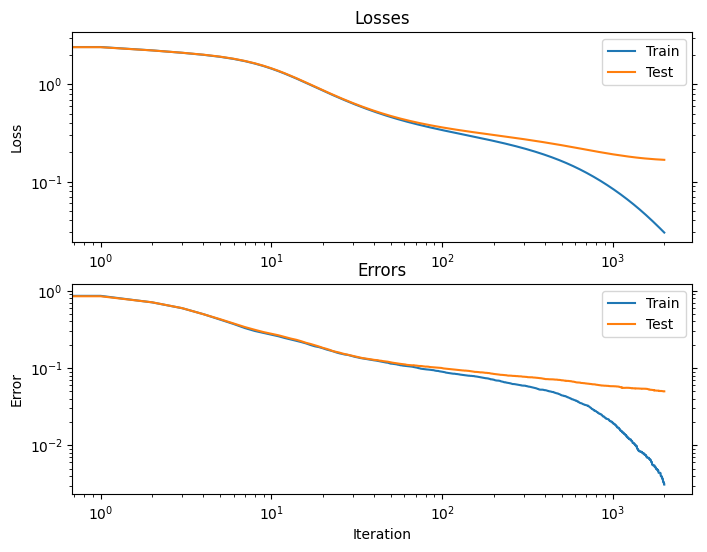

In [ ]:
H = 1000
scales={'w0':1, 'h0':1, 'w1':1, 'h1':1}
W0 = initWeights(H, scales=scales)

Xtr = torch.tensor(Xtrain_t[:10000], dtype=torch.float).to(device)
Ytr = Ytrain_t[:10000].to(device)
Xtst = torch.tensor(Xtest_t, dtype=torch.float).to(device)
Ytst = Ytest_t.to(device)

res = trainModel(W0, Xtr, Ytr, Xtst, Ytst, Niter=2000, lr=1e-3, scales=scales)

def showLossesAndErrors(res):
    print ('\n=== Training results ==== ')
    print ('Initial Train error:', res['errTrainL'][0])
    print ('Initial Test error:', res['errTestL'][0])
    print ('Final Train error:', res['errTrainL'][-1])
    print ('Final Test error:', res['errTestL'][-1])

    plt.figure(figsize=(8,6))
    ax = plt.subplot(2,1,1)
    plt.loglog(res['lossTrainL'], label='Train')
    plt.loglog(res['lossTestL'], label='Test')
    #plt.xlabel('Iteration')
    plt.ylabel('Loss')
    ax.yaxis.set_ticks_position('both')
    plt.legend()
    plt.title('Losses')

    ax = plt.subplot(2,1,2)
    plt.loglog(res['errTrainL'], label='Train')
    plt.loglog(res['errTestL'], label='Test')
    plt.xlabel('Iteration')
    plt.ylabel('Error')
    ax.yaxis.set_ticks_position('both')
    plt.legend()
    plt.title('Errors')

    plt.show()

showLossesAndErrors(res)

В общем случае, в ходе обучения эволюционируют все веса сети.

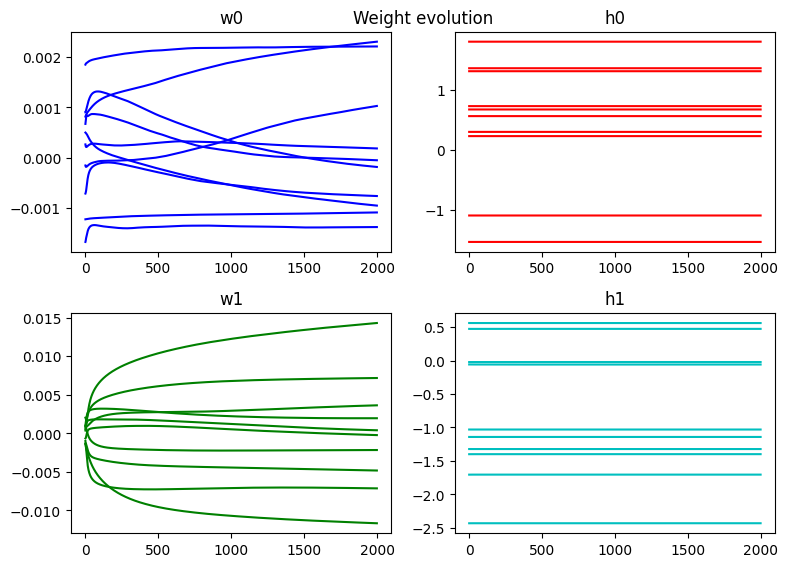

In [ ]:
def showWeights(res):
    plt.figure(figsize=(8,6))
    plt.title('Weight evolution')
    plt.axis('off')
    Wevol = res['Wevol']
    K = Wevol[0].shape[0]
    for k in range(4):
        plt.subplot(2,2,k+1)
        plt.title(['w0', 'h0', 'w1', 'h1'][k])
        wEvol = Wevol[k].detach().cpu().numpy()
        for r in range(K):
            plt.plot(wEvol[r], ['b', 'r', 'g', 'c'][k])
    plt.tight_layout()
    plt.show()

showWeights(res)

Применение построенной модели к конкретным примерам показывает, что ошибочных предсказаний действительно становится еще меньше, и ошибки в основном происходят на нестандартных изображениях. Тем не менее, модель все еще не достигает точности человека.  

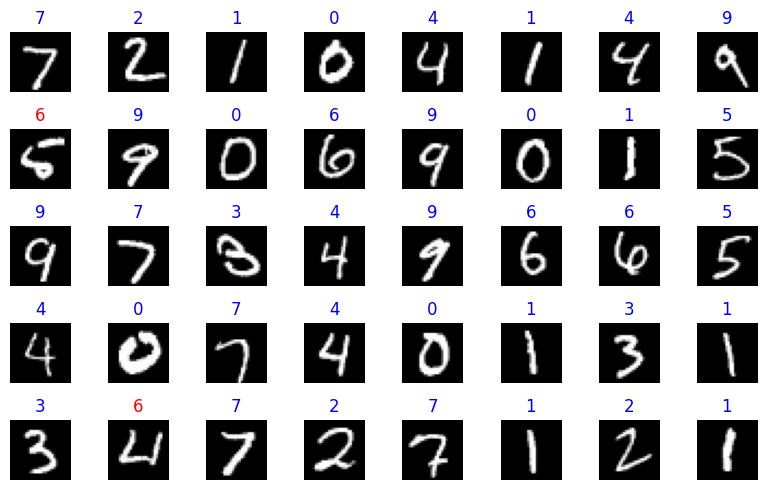

In [ ]:
YtestPred = getPred1H(Xtst, res['W'], scales=scales)

plt.figure(figsize=(8,5))
for n in range(40):
    plt.subplot(5,8,n+1)
    plt.imshow(Xtest[n], cmap='gray')
    predClass = int(torch.argmax(YtestPred[n]))
    plt.title(predClass, color=['r','b'][int(predClass==Ytest[n])])
    plt.axis('off')
plt.tight_layout()
plt.show()

Заметим, что нейронная сеть под конец обучения довольно сильно переобучается - гораздо сильнее, чем рассматривавшаяся ранее модель ближайших центров. Это неудивильно, так как нейронная сеть содержит гораздо больше параметров. Основной объем параметров приходится на веса первого слоя - их порядка $10^6$. Во втором слое параметро гораздо меньше - порядка $10^4$.

С помощью перемасштабирования некоторых весов мы можем заморозить их обучение. Например, мы можем отключить обучение первого признакового слоя, получая тем самым чисто линейную ядерную модель со сравнительно небольшим числом обучаемых параметров. Она имеет несколько меньшую точность, но не переобучается так сильно, как полная модель.  


=== Training results ==== 
Initial Train error: 0.8999000191688538
Initial Test error: 0.9020000100135803
Final Train error: 0.03550004959106445
Final Test error: 0.06940001249313354


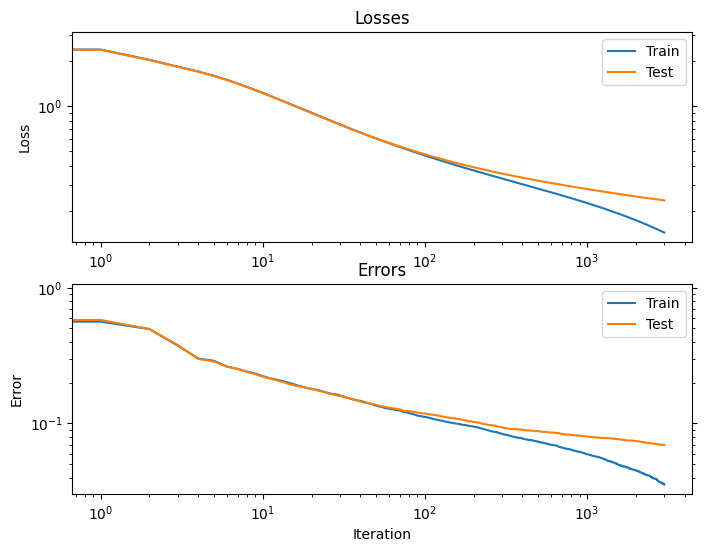

In [ ]:
scales={'w0':1e-2, 'h0':1, 'w1':1, 'h1':1}
W0 = initWeights(H, scales=scales)

res = trainModel(W0, Xtr, Ytr, Xtst, Ytst, Niter=3000, lr=5e-3, scales=scales)

showLossesAndErrors(res)

Проверка показывает, что веса вервого слоя действительно почти не меняются.

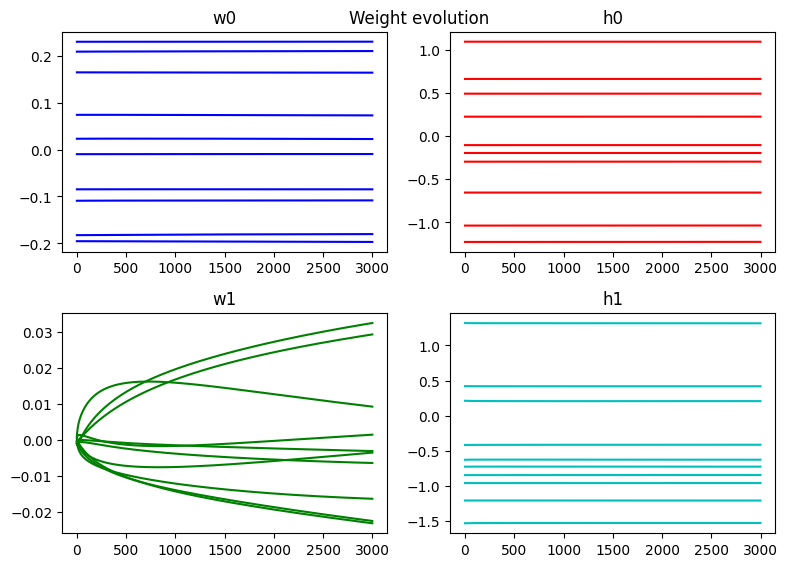

In [ ]:
showWeights(res)

### Глубокие нейронные сети

**Многослойная нейронная сети: общая мотивация и структура.** Стандартная многослойная полносвязная нейронная сеть представляет собой естественное обобщение однослойной сети, в котором слои расположены последовательно, и сигнал передается между соседними слоями. Предполагая, что сеть имеет $L$ слоев скрытых нейронов, мы можем записать ее действие в $l$-м слое как

$$x_{i}^{(l)}=\sigma\Big(\sum_{j=1}^{h_{l-1}}w_{ij}^{(l)}x^{(l-1)}_j+b^{(l)}_i\Big),\quad i\in\overline{1,h_l},\quad l\in\overline{1,L}.$$

Здесь $w_{ij}^{(l)}, b^{(l)}$ - веса слоя, $h_l$ - ширина слоя, $x_{i}^{(l)}$ - компоненты выходного сигнала (они же являются компонентами входного сигнала для следующего слоя). При $l=1$ входные сигналы слоя $x^{(0)}_j$ равны входным сигналам сети. В последнем, выходном слое сети функция активации не применяется. Пример графического изображения сети (при $L=3$):

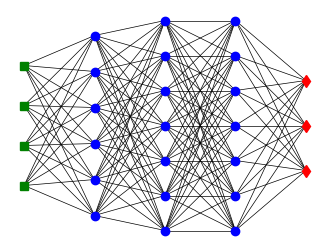

In [ ]:
Ninputs = 4
Noutputs = 3
L = 3
Nhidden = [6, 7, 7]
assert len(Nhidden) == L

inputs = np.linspace(start=-Ninputs, stop=Ninputs, num=Ninputs, endpoint=True)
outputs = np.linspace(start=-Noutputs, stop=Noutputs, num=Noutputs, endpoint=True)
hidden = [np.linspace(start=-h, stop=h, num=h, endpoint=True) for h in Nhidden]

plt.figure(figsize=(4,3))

for i in inputs:
    for j in hidden[0]:
        plt.plot([0, 1/(L+1)], [i,j], 'k', lw=0.5)

for l in range(L-1):
    for i in hidden[l]:
        for j in hidden[l+1]:
            plt.plot([(l+1)/(L+1), (l+2)/(L+1)], [i,j], 'k', lw=0.5)

for i in hidden[-1]:
    for j in outputs:
        plt.plot([L/(L+1), 1], [i,j], 'k', lw=0.5)

plt.plot(np.zeros(Ninputs), inputs, 'sg')
for l in range(L):
    plt.plot((l+1)/(L+1)*np.ones(Nhidden[l]), hidden[l], 'ob')
plt.plot(np.ones(Noutputs), outputs, 'dr')

plt.axis('off')

plt.show()

На практике часто используются различные модификации этой базовой структуры. Например, непосредственно соединяться могут не только соседние слои (skip connections) или напротив, в *разреженной* сети часть соединений между слоями может опускаться.

С глубокими нейронными сетями связан естественный вопрос, который мы попытаемся прояснить в оставшейся части этого раздела: чем глубокие сети лучше неглубоких? Ранее мы привели аргументы, показывающие, что линейные модели с дополнительными признаками (т.е. ядерные) решают проблему недостаточной выразительности исходных линейных моделей, а однослойные нейронные сети могут еще и адаптировать признаки к задаче. Какой конкретный дополнительный выигрыш могут давать глубокие сети?  

Приведем сначала некоторые общие соображения. Один слой нейронной сети можно представлять как модель параллельных вычислений. Каждый нейрон производит свое вычисление независимо от других нейронов этого слоя. Однако реальные алгоритмы имеют скорее последовательную, нежели параллельную общую структуру: совершаемые операции производятся над объектами, полученными в результате предыдущих операций. Хотя многие алгоритмы допускают параллелизацию, она часто приводит к потере эффективности с точки зрения общего объема вычислений - иногда очень значительной.  

Ограничение глубины нейронной сети фактически заставляет ее максимально параллелизовать вычисления. Мы приведем два (родственных) примера конкретных теоретических задач, в которых легко доказать, что ограничение глубины требует значительного увеличения суммарного числа операций в нейронной сети. Сначала мы покажем, что наши задачи сравнительно легко решаются с помощью конкретных сетей растущей глубины, а потом покажем, что такая эффективность недостижима при ограничении глубины.

**Пример 1: задача извлечения младшего бита.** Предположим, что число $a$ лежит в интервале $[0,1)$ и имеет вид $a=\frac{k}{2^N}$ с некоторым натуральным $N$ и $k\in\{0,1,\ldots, 2^N-1\}$. Иными словами, число $a$ имеет конечное двоичное представление $a=0.b_1b_2\ldots b_N$ с битами $b_i\in \{0,1\}$. Мы хотим сконструировать нейронную сеть, которая определяла бы по числу $a$ его *младший бит* $b_N$.

(Оговоримся, что эта задача несколько искусственная, так как числа и так представляются в компьютере в двоичном виде. Можно, однако, рассмотреть варианты этой задачи, в которых искомый объект уже не содержится напрямую во входных данных - например, вариант с *троичным* представлением.)   

Покажем, что данная задача легко решается, если взять сеть глубины $N$ с единственным нейроном в каждом слое, и использовать следующую кусочно-линейную функцию активации с одним разрывом:

$$\sigma(x)=\begin{cases}2x,& x<\tfrac{1}{2}\\ 2x-1,& x\ge \tfrac{1}{2} \end{cases}.$$

Действительно, желаемый бит $b_N$ можно найти с помощью последовательных сдвигов битового представления. А именно, заметим сначала, что первый бит $b_1$ можно найти как $\lfloor 2a\rfloor,$ где $\lfloor x\rfloor$ обозначает целую часть $x$. Разность $2a-\lfloor 2a\rfloor$ отвечает числу $0.b_2\ldots b_N,$ получаемому из $a$ отбрасыванием первого бита и сдвигом всех остальных битов влево. Совершая последовательные сдвиги с помощью операции $x\mapsto 2x-\lfloor 2x\rfloor$, через $N-1$ шаг мы получим число $0.b_N$. Умножая его на 2, получаем желаемое значение $b_N$. Заметим теперь, что аргумент $x$ операции $x\mapsto 2x-\lfloor 2x\rfloor$ в ходе применения алгоритма всегда лежит в интервале $[0,1),$ и на этом интервале данная операция задается приведенной выше формулой.


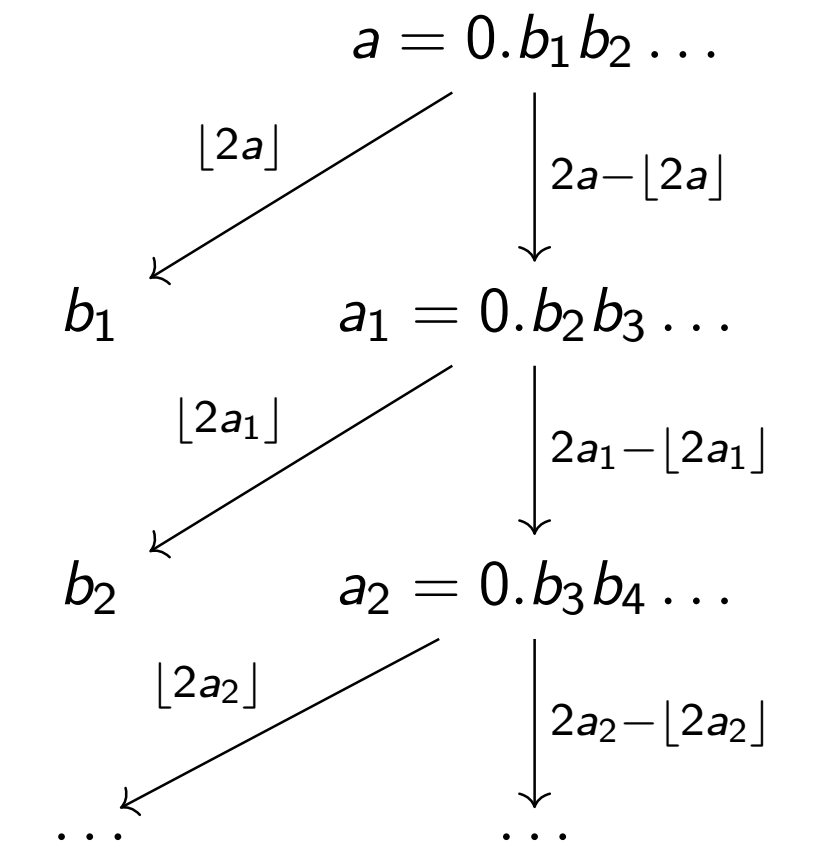

Подчеркнем следующие ключевые аспекты предложенного решения.

1. Рассмотренная нами процедура является принципиально последовательной, а не параллельной: двоичные сдвиги выполняются друг за другом.

2. Глубина, число нейронов и общее число операций в сети (арифметических и применений функций ативации) при увеличении $N$ растут пропорционально $N$.

3. Отбрасывание целой части (вычитание величины $\lfloor 2x\rfloor$ в ходе операции $x\mapsto 2x-\lfloor 2x\rfloor$) является важным элементом решения, так как позволяет применять функцию активации с одним разрывом на ограниченном интервале $[0,1)$. В противном случае нам пришлось бы использовать функцию активации, применимую на расширяющемся семействе интервалов и имеющую растущее число разрывов.

Можно показать, что вместо указанной нестандартной функции активации $\sigma$ можно использовать и стандартные кусочно-линейные функции активации, такие как ReLU, хотя при этом понадобится больше одного нейрона в слое (см. следующую задачу).  

**Пример 2: задача аппроксимации функции $x^2$.** Предположим, что мы хотим реализовать по возможности точное приближение функции $x^2$ на отрезке $[0,1]$ с помощью ReLU-сети. Это можно сделать так. Рассмотрим на отрезке $[0,1]$ функцию $g(x)$, имеющую вид "зубца", составленного из двух линейных участков:

$$\begin{align}
g(x)={}& \begin{cases}
2x, & x < \frac{1}{2}\\
2(1-x), & x\ge\frac{1}{2}
\end{cases}
\\
={}& 2(x)_+-4(x-0.5)_+,
\end{align}$$

где $(x)_+=\max(x,0)$ - функция ReLU. Рассмотрим $m$-кратную итерацию этой функции:

$$g_m(x) = \underbrace{g\circ g\circ\cdots \circ g}_m(x).$$

Такая функция имеет "пилообразную" форму с $2^{m-1}$ зубцами.


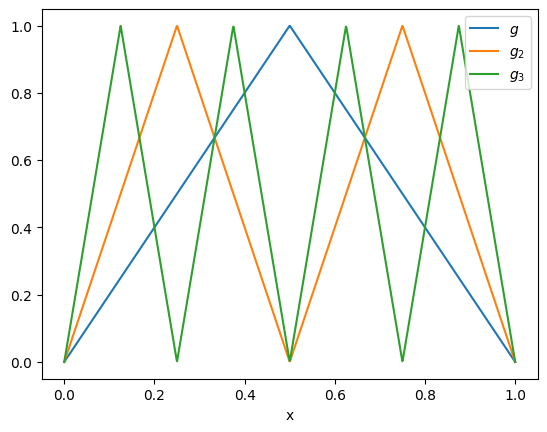

In [ ]:
def g(x, m=1):
    if m == 1:
        return 2*np.maximum(x,0)-4*np.maximum(x-0.5, 0)
    else:
        return g(g(x, m-1))

x = np.linspace(0,1,1000)

plt.plot(x, g(x), label='$g$')

for m in range(2, 4):
    plt.plot(x, g(x, m), label='$g_%d$' %(m))

plt.xlabel('x')
plt.legend()
plt.show()

Введем теперь функции

$$f_m(x)=x-\sum_{k=1}^m \frac{g_k(x)}{2^{2k}}$$

Легко видеть (**упражнение**), что они образуют приближения к функции $x^2$, которые сходятся *экспоненциально быстро*:

$$\max_{x\in[0,1]}|f_m(x)-x^2|=\frac{1}{2^{2m+2}}.$$

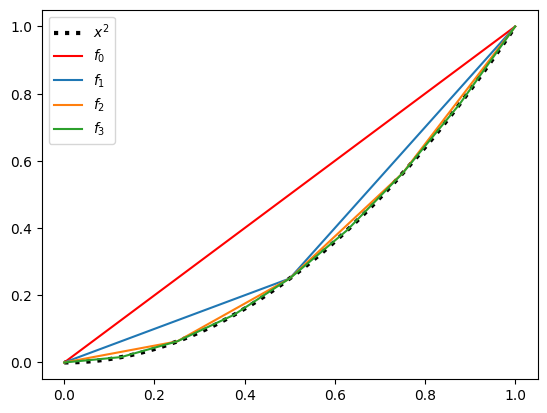

In [ ]:
plt.plot(x, x**2, ':k', lw=3, label='$x^2$')

f = 1*x
plt.plot(x, f, 'r', label='$f_0$')

for m in range(1,4):
    f -= g(x,m)/2**(2*m)
    plt.plot(x, f, label='$f_%d$' %(m))

plt.legend()
plt.show()

Вычисление функции $f_m$ можно реализовать в виде ReLU сети с $m$ скрытыми слоями, каждый из которых содержит два ReLU-нейрона, дополнительно соединяющихся с выходным нейроном:

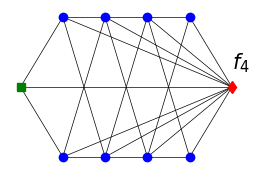

In [ ]:
Ninputs = 1
Noutputs = 1
L = 4
Nhidden = L*[2]


inputs = np.linspace(start=0, stop=0, num=Ninputs, endpoint=True)
outputs = np.linspace(start=0, stop=0, num=Noutputs, endpoint=True)
hidden = [0.0*(i+1)+np.linspace(start=-h, stop=h, num=h, endpoint=True) for i, h in enumerate(Nhidden)]

plt.figure(figsize=(3,2))

for i in inputs:
    plt.plot([0, 1], [i,0], 'k', lw=0.5)
    for j in hidden[0]:
        plt.plot([0, 1/(L+1)], [i,j], 'k', lw=0.5)

for l in range(L-1):
    for i in hidden[l]:
        plt.plot([(l+1)/(L+1), 1], [i,0], 'k', lw=0.5)
        for j in hidden[l+1]:
            plt.plot([(l+1)/(L+1), (l+2)/(L+1)], [i,j], 'k', lw=0.5)

for i in hidden[-1]:
    for j in outputs:
        plt.plot([L/(L+1), 1], [i,j], 'k', lw=0.5)

plt.plot(np.zeros(Ninputs), inputs, 'sg')
for l in range(L):
    plt.plot((l+1)/(L+1)*np.ones(Nhidden[l]), hidden[l], 'ob')
plt.plot(np.ones(Noutputs), outputs, 'dr')

plt.text(1, 0.5, '$f_%d$' %(L), fontsize=15)

plt.axis('off')

plt.show()

Заметим, что функции $g_N$ можно использовать и для решения предыдущей задачи извлечения младшего бита, поскольку чередующиеся значения 0 и 1 в изломах такой функций cовпадают с чередующимися значениями $b_N$ младшего бита чисел $x=\tfrac{k}{2^N}, k = 0,1,2,\ldots$:

$$b_N=g_N(x).$$

Соответствующая ReLU-сеть обходится без прямых соединений между скрытыми нейронами и выходным нейронов:

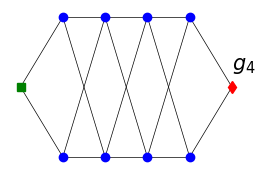

In [ ]:
Ninputs = 1
Noutputs = 1
L = 4
Nhidden = L*[2]


inputs = np.linspace(start=0, stop=0, num=Ninputs, endpoint=True)
outputs = np.linspace(start=0, stop=0, num=Noutputs, endpoint=True)
hidden = [0.0*(i+1)+np.linspace(start=-h, stop=h, num=h, endpoint=True) for i, h in enumerate(Nhidden)]

plt.figure(figsize=(3,2))

for i in inputs:
    for j in hidden[0]:
        plt.plot([0, 1/(L+1)], [i,j], 'k', lw=0.5)

for l in range(L-1):
    for i in hidden[l]:
        for j in hidden[l+1]:
            plt.plot([(l+1)/(L+1), (l+2)/(L+1)], [i,j], 'k', lw=0.5)

for i in hidden[-1]:
    for j in outputs:
        plt.plot([L/(L+1), 1], [i,j], 'k', lw=0.5)

plt.plot(np.zeros(Ninputs), inputs, 'sg')
for l in range(L):
    plt.plot((l+1)/(L+1)*np.ones(Nhidden[l]), hidden[l], 'ob')
plt.plot(np.ones(Noutputs), outputs, 'dr')

plt.text(1, 0.5, '$g_%d$' %(L), fontsize=15)

plt.axis('off')

plt.show()

**Невозможность реализации сетью с ограниченным числом слоев.** Покажем теперь, что эффективности приведенных глубоких решений нельзя добиться, если использовать сети с ограниченным числом слоев.

Пусть $\sigma$ - некоторая фиксированная кусочно-линейная функция активации с *единственной* точкой излома или разрыва, например ReLU $\sigma(x)=\max(x,0)$ или использованная в первой задаче функция $\sigma(x)=\begin{cases}2x,& x<\tfrac{1}{2}\\ 2x-1,& x\ge \tfrac{1}{2} \end{cases}.$

Рассмотрим нейронную сеть с этой функцией активации, имеющую один входной и один выходной нейроны, то есть реализующую некоторую функцию $\widehat f:\mathbb R\to\mathbb R$. Пусть сеть имеет $L$ скрытых слоев, и каждый слой содержит не более $H$ нейронов. Будем предполагать, что нейрон получает на вход сигналы только из предыдущих слоев - но не своего и не последующих (при этом мы допускаем наличие прямых связей между несоседними слоями).

**Утверждение.** *При сделанных предположениях реализуемая функция $\widehat f$ является кусочно-линейной в том смысле, что имеется конечное число особых точек $x_1 < x_2 < \ldots < x_{M-1}$ таких, что на каждом из $M$ интервалов $(-\infty, x_1), \{(x_k, x_{k+1})\}_{k=1}^{M-2}$ и $(x_{M-1},+\infty)$ функция $f$ линейна, т.е. имеет вид $f(x)=ax+b$ с некоторыми $a,b$. Количество $M$ интервалов линейности  не превосходит $(H+1)^L$.*   

**Доказательство.** Пусть $l\in \overline{0,L}$ обозначает номер слоя скрытых нейронов или, в случае $l=0$, входной слой сети. Покажем по индукции, что существет не более $(H+1)^{l}-1$ особых точек таких, что *все* нейроны первых слоев вплоть до $l$-го включительно реализуют линейные функции на интервалах разбиения множества $\mathbb R$ данными точками.

Базис индукции отвечает $l=0$: входной нейрон реализует тождественную функцию $f(x)=x,$ не имеющую особых точек.

Сделаем шаг индукции, предполагая, что утверждение уже установлено для слоя $l-1$. Пусть $I$ - какой-либо интервал, на котором все нейроны слоев вплоть до $(l-1)$-го реализуют линейные функции. Мы покажем, что этот интервал можно разбить на не более чем $H+1$ подинтервалов так, чтобы и нейроны $l$-го слоя реализовывали на них линейные функции.

Рассмотрим некоторый нейрон $l$-го слоя. Его действие можно записать в виде $\sigma(\sum_i w_i f_i(x)+b),$ где $\sum_i w_i f_i(x)$ - некоторая линейная комбинация выходов $f_i(x)$ нейронов из предыдущих слоев. Согласно нашему предположению, все функции $f_i$ линейны на интервале $I$, поэтому их линейная комбинация $\sum_i w_i f_i(x)$ также линейна. Таким образом, при $x\in I$ на вход нашего нейрона поступает некоторая линейная функция $g(x)=ax+b$. Вспомним теперь, что согласно нашему предположению, функция активации $\sigma$ имеет единственную точку сингулярности $s_*$; слева и справа от нее $\sigma$ линейна. Заметим, что линейная функция $g(x)$ на интервале $I$ либо не равна $s_*$ нигде, либо равна в единственной точке $x_*$, либо тождественно равна $s_*$. В первом и последнем случаях реализуемая нейроном функция $\sigma(g(x))$ линейна по $x$ на всем интервале $I$. Во втором случае эта функция линейна на по $x$ по отдельности на двух подинтервалах в $I$, получаемых удалением из него точки $s_*$. Таким образом, один нейрон порождает самое большее одну особую точку на интервале $I$, слева и справа от которой его действие линейно.

Если взять теперь все нейроны $l$-го слоя (которых не более $H$), то им суммарно отвечает не более чем $H$ особых точек, разбивающих интервал $I$ на $H+1$ или меньшее число подинтервалов. На каждом из этих подинтервалов действие каждого из нейронов $l$-го слоя линейна. По предположению индукции количество интервалов $I$ линейности нейронов в слоях вплоть до $(l-1)$-го не превосходит $(H+1)^{l-1}$. Умножая на $H+1,$ получаем, что количество интервалов линейности нейронов в слоях вплоть до $l$-го не превосходит $(H+1)^{l}$, завершая шаг индукции.

Остается заметить, что выход сети образуется как линейная комбинация нейронов предыдущих слоев, поэтому любой интервал $I$ линейности всех скрытых нейронов будет таким интервалом и для выхода всей сети. Таким образом, выход сети линеен на каждом из не более чем $(H+1)^{l}$ интервалов, получаемых разбиением $\mathbb R$ особыми точками. Ч.Т.Д.

Из доказанного утверждения следует простое

**Следствие.** *Пусть кусочно-линейная функция с $M$ интервалами линейности реализуется нейронной сеть с $L$ скрытыми слоями, причем которой функция активации кусочно-линейна с одной особой точкой. Тогда максимальная ширина слоя сети не меньше $M^{1/L}-1$.*

Возвращаясь теперь к рассмотренным задачам извлечения младшего бита и приближения функции $x^2,$ покажем, что их решение с помощью кусочно-линейной функции требует большого числа интервалов линейности.

- **Извлечение младшего бита.** Когда числитель $k$ дроби $x=\tfrac{k}{2N}$ пробегает значения от 0 до $2^N-1$, значения младшего бита $b_N$ числа $x$ последовательно чередуются между 0 и 1. Если предположить, что эти значения задаются некоторой кусочно-линейной функцией $f(x),$ то каждый ее интервал линейности может содержать не более двух соседних точек $\tfrac{k}{2N}$. Таким образом, функция должна иметь не менее $2^{N-1}$ интервалов линейности.

- **Аппроксимация $x^2$.** Пусть кусочно-линейная функция $f$ равномерно приближает функцию $x^2$ на отрезке $[0,1]$ с точностью $\epsilon,$ т.е. $|f(x)-x^2|\le \epsilon$ для всех $x\in[0,1]$. Покажем, что любой интервал линейности $[a,b]$ функции $f$ не длиннее $\sqrt{8\epsilon}$. Для этого сделаем линейную замену переменных $x=g(x')=\tfrac{b+a}{2}+\tfrac{b-a}{2}x'$, переводящую точки $x\in[a,b]$ в точки $x'\in[-1,1]$. Композиция $f\circ g$ линейна на $[-1,1]$ и  аппроксимирует на нем многочлен второй степени $(\tfrac{b+a}{2}+\tfrac{b-a}{2}x')^2$ с точностью $\epsilon$. Это означает, что функцию $\frac{(b-a)^2}{4}x'^2$ можно приблизить на отрезке $[-1,1]$ линейными функциями с точностью $\epsilon$. Легко видеть, что это возможно лишь если $\frac{(b-a)^2}{4}\le 2\epsilon,$ то есть $b-a\le \sqrt{8\epsilon}.$
\
Таким образом, количество интервалов линейности, необходимое для равномерного приближения функции $x^2$ на отрезке $[0,1]$ линейными функциями с точностью $\epsilon$, не меньше $\tfrac{1}{\sqrt{8\epsilon}}$.

Пользуясь доказанным выше утверждением, покажем теперь, что неглубокие сети, в отличие от рассмотренных ранее глубоких, требуют большого числа нейронов в каждом слое.

- **Извлечение младшего бита.** Поскольку извлекающая младший бит $b_N$ кусочно-линейная функция имеет не менее $2^{N-1}$ интервалов линейности, из приведенного Следствия следует, что соответствующая нейронная сеть с $L$ скрытыми слоями не может иметь менее $2^{(N-1)/L}-1$ нейронов в наиболее широком слое. Заметим, что при любом фиксированном $L$ это значение растет *экспоненциально быстро* по $N$. Для сравнения, приведенная нами ReLU сеть глубины $N$ содержит лишь два нейрона в каждом слое. Пусть, например $N=20$; сеть с $L=2$ скрытыми слоями тогда содержит не менее $500$ нейронов в наиболее широком слое, тогда как наша глубокая сеть содержит в общей сложности всего лишь 40 нейронов.

- **Аппроксимация $x^2$.** Напомним, что построенная нами сеть глубины $m$ с двумя нейронами в каждом скрытом слое давала точность аппроксимации $\epsilon=2^{-2m-2}.$ Из полученной выше оценки следует, что аппроксимация такой точности требует не менее $\frac{1}{\sqrt{8\epsilon}}=2^{m-1/2}$ интервалов линейности, и в случае сети с $L$ скрытыми слоями наиболее широкий слой имеет не менее $2^{(m-1/2)/L}-1$ нейронов. Мы снова видим, что для любой фиксированной глубины $L$ число нейронов растет экспоненциально по $m$.





### TODO

- Эксперименты с глубокими сетями (MNIST). Эксперименты с батчевым обучением.

- Вычисления на GPU

- Классические линейные параметрические аппроксимационные модели. Полиномиальная модель. Достоинства и недостатки по сравнению с нейронными сетями (линейность по весам, "проклятие размерности", плохо контролируемый рост, ..) Сплайны (линейные, кубические). Достоинства и недостатки.
